# EDA: Main Features

Глубокий анализ `train_main_features.parquet` с фокусом на:
1. Структура данных и типы
2. Анализ пропусков (паттерны, MCAR/MAR гипотезы)
3. Категориальные признаки (кардинальность, частоты)
4. Числовые признаки (распределения, выбросы, корреляции)
5. Связь признаков с таргетами
6. Covariate shift: train vs test
7. Выводы и рекомендации

In [17]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

## 1. Загрузка данных

In [18]:
train = pl.read_parquet('train_main_features.parquet')
test  = pl.read_parquet('test_main_features.parquet')
target = pl.read_parquet('train_target.parquet')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
print(f'Target:{target.shape}')

Train: (750000, 200)
Test:  (250000, 200)
Target:(750000, 42)


In [19]:
# Разбиваем признаки по типам
cat_cols = [c for c in train.columns if c.startswith('cat_feature')]
num_cols = [c for c in train.columns if c.startswith('num_feature')]
target_cols = [c for c in target.columns if c.startswith('target')]

print(f'Категориальных признаков: {len(cat_cols)}')
print(f'Числовых признаков:       {len(num_cols)}')
print(f'Таргетов:                 {len(target_cols)}')

Категориальных признаков: 67
Числовых признаков:       132
Таргетов:                 41


## 2. Анализ пропусков

### 2.1 Общая картина

In [20]:
n = len(train)

missing = (
    train.null_count()
    .unpivot(variable_name='col', value_name='n_missing')
    .filter(pl.col('n_missing') > 0)
    .with_columns((pl.col('n_missing') / n * 100).alias('pct_missing'))
    .sort('pct_missing', descending=True)
)

# Разбивка по типу
missing = missing.with_columns(
    pl.when(pl.col('col').str.starts_with('cat'))
    .then(pl.lit('categorical'))
    .otherwise(pl.lit('numerical'))
    .alias('feat_type')
)

print(f'Признаков с пропусками: {len(missing)} из {len(train.columns)-1}')
print(f'\nТоп-10 по % пропусков:')
print(missing.head(10))

Признаков с пропусками: 132 из 199

Топ-10 по % пропусков:
shape: (10, 4)
┌─────────────────┬───────────┬─────────────┬───────────┐
│ col             ┆ n_missing ┆ pct_missing ┆ feat_type │
│ ---             ┆ ---       ┆ ---         ┆ ---       │
│ str             ┆ u32       ┆ f64         ┆ str       │
╞═════════════════╪═══════════╪═════════════╪═══════════╡
│ num_feature_43  ┆ 749166    ┆ 99.8888     ┆ numerical │
│ num_feature_54  ┆ 748897    ┆ 99.852933   ┆ numerical │
│ num_feature_64  ┆ 748761    ┆ 99.8348     ┆ numerical │
│ num_feature_34  ┆ 748228    ┆ 99.763733   ┆ numerical │
│ num_feature_118 ┆ 747082    ┆ 99.610933   ┆ numerical │
│ num_feature_74  ┆ 746865    ┆ 99.582      ┆ numerical │
│ num_feature_81  ┆ 746462    ┆ 99.528267   ┆ numerical │
│ num_feature_75  ┆ 742601    ┆ 99.013467   ┆ numerical │
│ num_feature_45  ┆ 741505    ┆ 98.867333   ┆ numerical │
│ num_feature_28  ┆ 738007    ┆ 98.400933   ┆ numerical │
└─────────────────┴───────────┴─────────────┴───────────

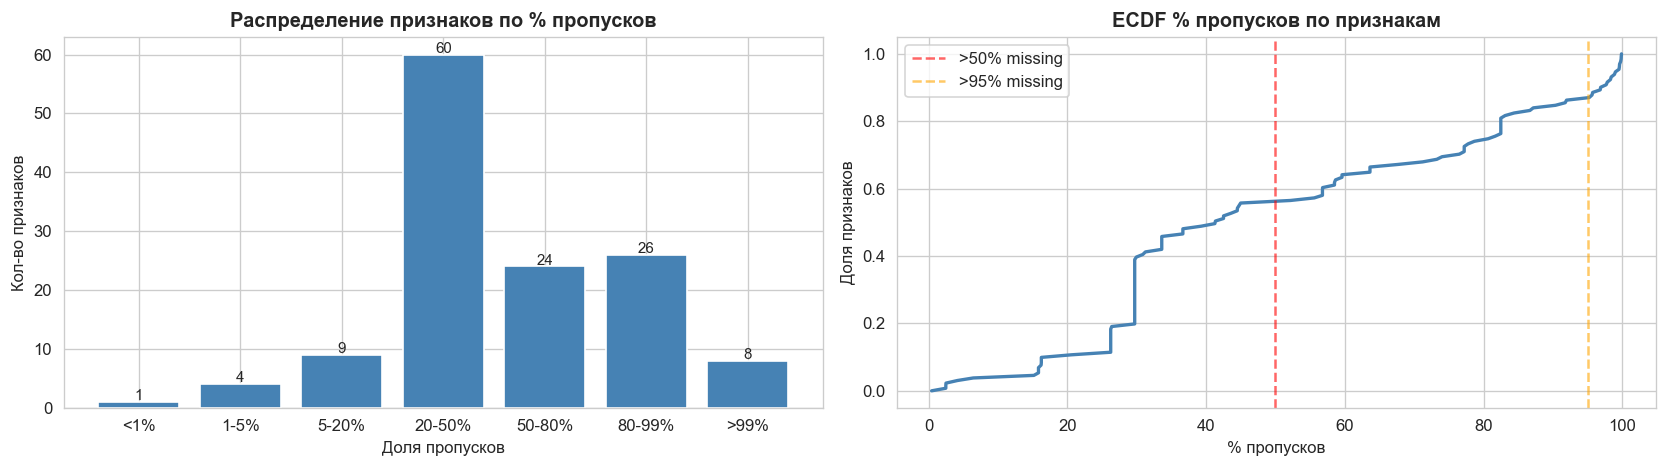

Признаков с >95% пропусков: 18
Признаков с >50% пропусков: 58
Признаков с <5% пропусков:  5


In [21]:
# Гистограмма % пропусков
pct = missing['pct_missing'].to_numpy()

bins = [0, 1, 5, 20, 50, 80, 99, 100]
labels = ['<1%', '1-5%', '5-20%', '20-50%', '50-80%', '80-99%', '>99%']
counts = np.histogram(pct, bins=bins)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Левый: бары по группам
axes[0].bar(labels, counts, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение признаков по % пропусков', fontweight='bold')
axes[0].set_xlabel('Доля пропусков')
axes[0].set_ylabel('Кол-во признаков')
for i, v in enumerate(counts):
    if v > 0:
        axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=9)

# Правый: ECDF
sorted_pct = np.sort(pct)
axes[1].plot(sorted_pct, np.linspace(0, 1, len(sorted_pct)), lw=2, color='steelblue')
axes[1].axvline(50, ls='--', color='red', alpha=0.6, label='>50% missing')
axes[1].axvline(95, ls='--', color='orange', alpha=0.6, label='>95% missing')
axes[1].set_title('ECDF % пропусков по признакам', fontweight='bold')
axes[1].set_xlabel('% пропусков')
axes[1].set_ylabel('Доля признаков')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Признаков с >95% пропусков: {(pct > 95).sum()}")
print(f"Признаков с >50% пропусков: {(pct > 50).sum()}")
print(f"Признаков с <5% пропусков:  {(pct < 5).sum()}")

### 2.2 Паттерны пропусков — MNAR гипотеза

Если факт пропуска сам по себе предсказывает таргет → данные **MNAR**, и индикаторы пропусков — ценные признаки.

In [22]:
# Берём только числовые признаки с > 5% пропусков
heavy_missing_num = (
    missing
    .filter((pl.col('feat_type') == 'numerical') & (pl.col('pct_missing') > 5))
    ['col'].to_list()
)
print(f'Числовых признаков с >5% пропусков: {len(heavy_missing_num)}')

# Создаём индикаторы пропусков
indicators = train.select([
    pl.col(col).is_null().cast(pl.Int8).alias(f'is_null_{col}')
    for col in heavy_missing_num
])

# Считаем, сколько клиентов имеют хотя бы один пропуск
any_missing = (indicators.sum_horizontal() > 0).alias('any_missing')
print(f'Клиентов хотя бы с одним пропуском (>5% cols): {train.select(any_missing).sum().item()}')

Числовых признаков с >5% пропусков: 127
Клиентов хотя бы с одним пропуском (>5% cols): 750000


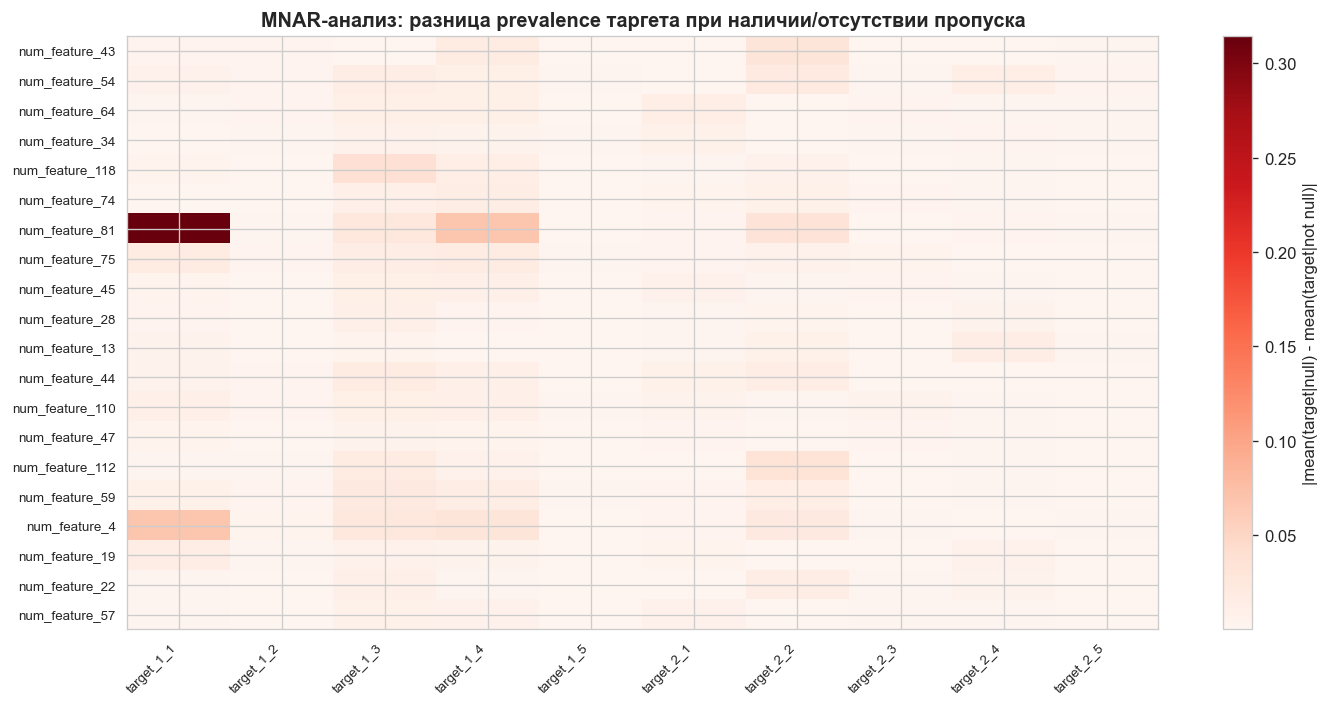


Топ-10 пар (признак, таргет) с наибольшей MNAR-сигналью:
shape: (10, 3)
┌─────────────────┬────────────┬──────────┐
│ feature         ┆ target     ┆ diff     │
│ ---             ┆ ---        ┆ ---      │
│ str             ┆ str        ┆ f64      │
╞═════════════════╪════════════╪══════════╡
│ num_feature_81  ┆ target_1_1 ┆ 0.314434 │
│ num_feature_81  ┆ target_1_4 ┆ 0.068187 │
│ num_feature_4   ┆ target_1_1 ┆ 0.067581 │
│ num_feature_118 ┆ target_1_3 ┆ 0.035641 │
│ num_feature_112 ┆ target_2_2 ┆ 0.03284  │
│ num_feature_81  ┆ target_2_2 ┆ 0.0319   │
│ num_feature_43  ┆ target_2_2 ┆ 0.029844 │
│ num_feature_4   ┆ target_1_4 ┆ 0.028378 │
│ num_feature_4   ┆ target_1_3 ┆ 0.026536 │
│ num_feature_81  ┆ target_1_3 ┆ 0.023811 │
└─────────────────┴────────────┴──────────┘


In [23]:
# Для топ-20 признаков с пропусками: разница в prevalence таргетов
# между группами "есть пропуск" vs "нет пропуска"
top_missing_cols = heavy_missing_num[:20]
target_means = target.select(target_cols).mean().row(0)  # baseline prevalence

mnar_scores = []
for col in top_missing_cols:
    is_null = train[col].is_null()
    for i, tcol in enumerate(target_cols[:10]):  # топ-10 таргетов для скорости
        t = target[tcol].to_numpy()
        null_mean = t[is_null.to_numpy()].mean()
        notnull_mean = t[~is_null.to_numpy()].mean()
        mnar_scores.append({
            'feature': col,
            'target': tcol,
            'diff': abs(null_mean - notnull_mean)
        })

mnar_df = pl.DataFrame(mnar_scores).sort('diff', descending=True)

# Pivot для heatmap
pivot_data = {}
for row in mnar_df.iter_rows(named=True):
    if row['feature'] not in pivot_data:
        pivot_data[row['feature']] = {}
    pivot_data[row['feature']][row['target']] = row['diff']

feat_order = top_missing_cols
tgt_order = target_cols[:10]
matrix = np.array([[pivot_data.get(f, {}).get(t, 0) for t in tgt_order] for f in feat_order])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(matrix, cmap='Reds', aspect='auto')
plt.colorbar(im, ax=ax, label='|mean(target|null) - mean(target|not null)|')
ax.set_xticks(range(len(tgt_order)))
ax.set_yticks(range(len(feat_order)))
ax.set_xticklabels(tgt_order, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feat_order, fontsize=8)
ax.set_title('MNAR-анализ: разница prevalence таргета при наличии/отсутствии пропуска', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nТоп-10 пар (признак, таргет) с наибольшей MNAR-сигналью:')
print(mnar_df.head(10))

### 2.3 Кластеры совместных пропусков

Признаков с 5-95% пропусков: 109


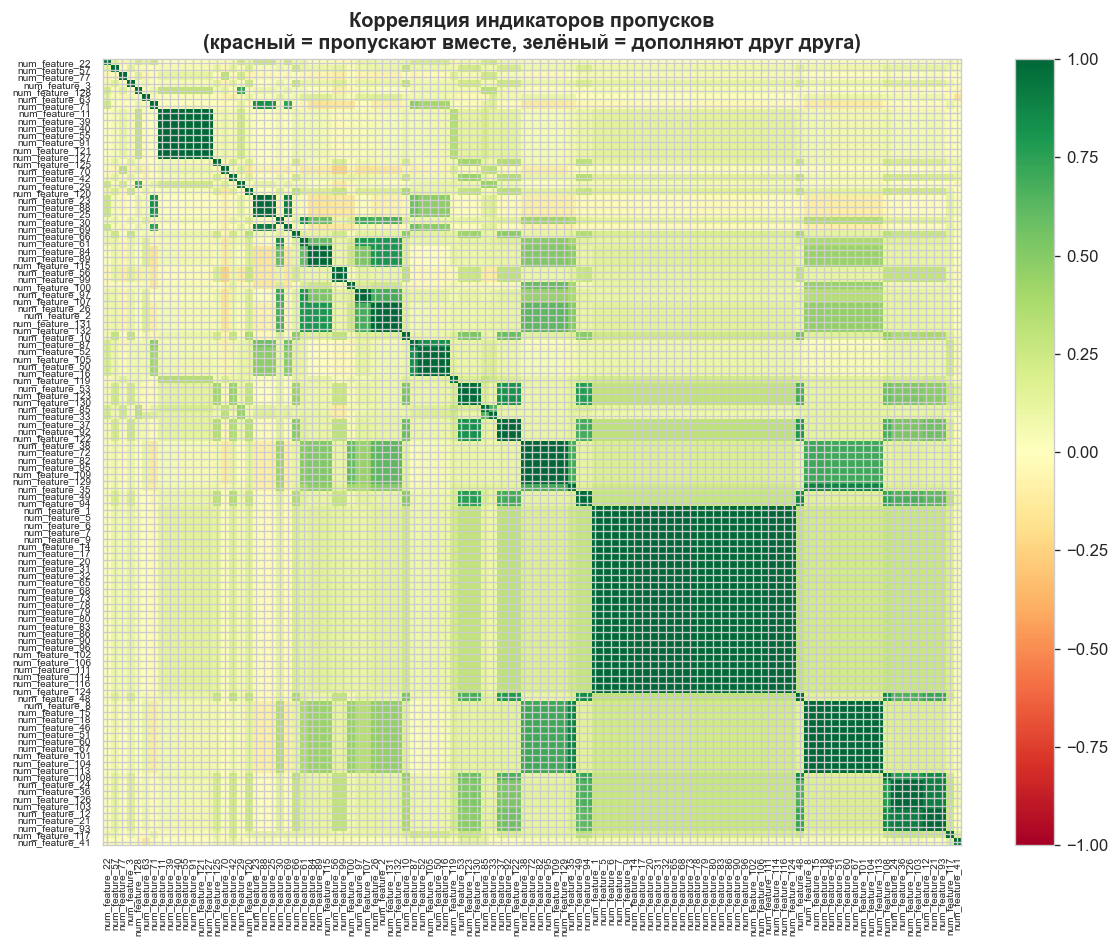

In [24]:
# Берём признаки с 5-95% пропусков — они наиболее информативны для кластеризации
mid_missing = (
    missing
    .filter(
        (pl.col('feat_type') == 'numerical') &
        (pl.col('pct_missing') > 5) &
        (pl.col('pct_missing') < 95)
    )
    ['col'].to_list()
)
print(f'Признаков с 5-95% пропусков: {len(mid_missing)}')

# Корреляция индикаторов пропусков
if len(mid_missing) > 1:
    null_indicators = train.select([
        pl.col(c).is_null().cast(pl.Int8) for c in mid_missing
    ]).to_numpy().T  # shape: (n_features, n_samples)

    corr_null = np.corrcoef(null_indicators)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_null, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title('Корреляция индикаторов пропусков\n(красный = пропускают вместе, зелёный = дополняют друг друга)',
                 fontweight='bold')
    ax.set_xticks(range(len(mid_missing)))
    ax.set_yticks(range(len(mid_missing)))
    ax.set_xticklabels(mid_missing, rotation=90, fontsize=6)
    ax.set_yticklabels(mid_missing, fontsize=6)
    plt.tight_layout()
    plt.show()

## 3. Анализ категориальных признаков

### 3.1 Кардинальность

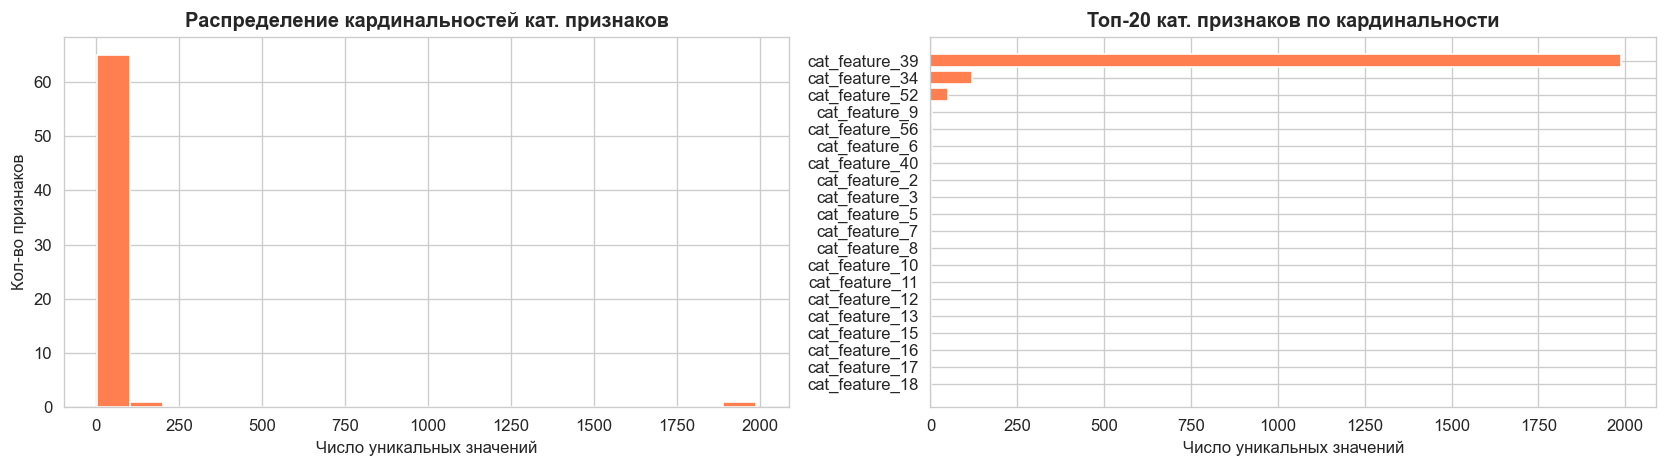

Кардинальность: min=2, median=3, max=1989
Признаков с кардинальностью > 50: 3


In [25]:
cat_cardinality = (
    train.select(cat_cols)
    .select([pl.col(c).n_unique().alias(c) for c in cat_cols])
    .unpivot(variable_name='feature', value_name='n_unique')
    .sort('n_unique', descending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма кардинальностей
cardinalities = cat_cardinality['n_unique'].to_numpy()
axes[0].hist(cardinalities, bins=20, color='coral', edgecolor='white')
axes[0].set_title('Распределение кардинальностей кат. признаков', fontweight='bold')
axes[0].set_xlabel('Число уникальных значений')
axes[0].set_ylabel('Кол-во признаков')

# Топ-20 по кардинальности
top20 = cat_cardinality.head(20)
axes[1].barh(top20['feature'].to_list()[::-1], top20['n_unique'].to_numpy()[::-1], color='coral')
axes[1].set_title('Топ-20 кат. признаков по кардинальности', fontweight='bold')
axes[1].set_xlabel('Число уникальных значений')

plt.tight_layout()
plt.show()

print(f"Кардинальность: min={cardinalities.min()}, median={np.median(cardinalities):.0f}, max={cardinalities.max()}")
print(f"Признаков с кардинальностью > 50: {(cardinalities > 50).sum()}")

### 3.2 Частотный анализ категориальных признаков

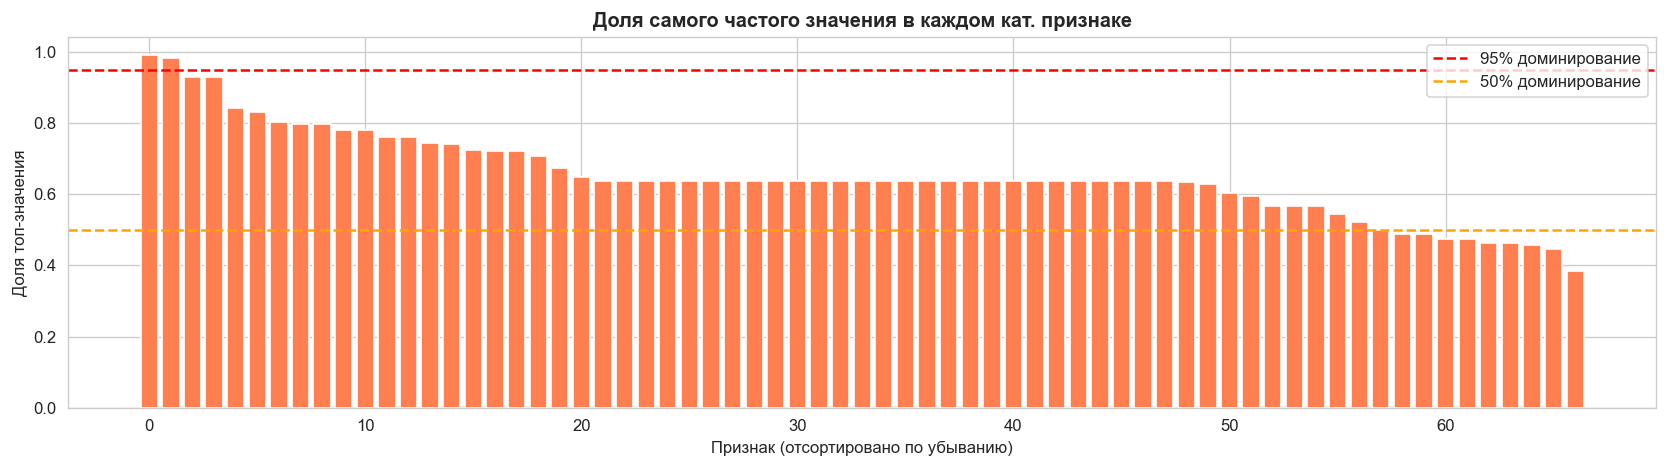

Почти константных кат. признаков (>99% одного значения): 1
shape: (1, 2)
┌────────────────┬──────────┐
│ feature        ┆ top_freq │
│ ---            ┆ ---      │
│ str            ┆ f64      │
╞════════════════╪══════════╡
│ cat_feature_34 ┆ 0.992408 │
└────────────────┴──────────┘


In [26]:
# Для каждого кат. признака: доля самого частого значения (доминирование)
dominance = []
for c in cat_cols:
    vc = train[c].value_counts(sort=True)
    top_freq = vc['count'][0] / n
    dominance.append({'feature': c, 'top_freq': top_freq})

dom_df = pl.DataFrame(dominance).sort('top_freq', descending=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(dom_df)), dom_df['top_freq'].to_numpy(), color='coral', width=0.8)
ax.axhline(0.95, color='red', ls='--', label='95% доминирование')
ax.axhline(0.50, color='orange', ls='--', label='50% доминирование')
ax.set_title('Доля самого частого значения в каждом кат. признаке', fontweight='bold')
ax.set_xlabel('Признак (отсортировано по убыванию)')
ax.set_ylabel('Доля топ-значения')
ax.legend()
plt.tight_layout()
plt.show()

near_constant = dom_df.filter(pl.col('top_freq') > 0.99)
print(f'Почти константных кат. признаков (>99% одного значения): {len(near_constant)}')
if len(near_constant) > 0:
    print(near_constant)

### 3.3 Train vs Test: покрытие категорий

In [27]:
# Какой % значений из test НЕ встречается в train?
unseen_in_test = []
for c in cat_cols:
    train_vals = set(train[c].drop_nulls().unique().to_list())
    test_vals  = set(test[c].drop_nulls().unique().to_list())
    new_in_test = test_vals - train_vals
    unseen_in_test.append({
        'feature': c,
        'n_new_cats': len(new_in_test),
        'pct_new': len(new_in_test) / max(len(test_vals), 1) * 100
    })

unseen_df = pl.DataFrame(unseen_in_test).sort('n_new_cats', descending=True)

has_new = unseen_df.filter(pl.col('n_new_cats') > 0)
print(f'Признаков с новыми категориями в test: {len(has_new)}')
if len(has_new) > 0:
    print(has_new.head(15))

Признаков с новыми категориями в test: 2
shape: (2, 3)
┌────────────────┬────────────┬──────────┐
│ feature        ┆ n_new_cats ┆ pct_new  │
│ ---            ┆ ---        ┆ ---      │
│ str            ┆ i64        ┆ f64      │
╞════════════════╪════════════╪══════════╡
│ cat_feature_39 ┆ 38         ┆ 2.005277 │
│ cat_feature_34 ┆ 13         ┆ 16.25    │
└────────────────┴────────────┴──────────┘


## 4. Анализ числовых признаков

### 4.1 Описательная статистика

In [28]:
# Базовая статистика числовых признаков (только те, у которых > 100 ненулевых)
num_stats = train.select(num_cols).describe()
print(num_stats)

shape: (9, 133)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ num_featu ┆ num_featu ┆ num_featu ┆ … ┆ num_featu ┆ num_featu ┆ num_featu ┆ num_feat │
│ ---       ┆ re_1      ┆ re_2      ┆ re_3      ┆   ┆ re_129    ┆ re_130    ┆ re_131    ┆ ure_132  │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 527213.0  ┆ 324201.0  ┆ 96219.0   ┆ … ┆ 497958.0  ┆ 439895.0  ┆ 324201.0  ┆ 324201.0 │
│ null_coun ┆ 222787.0  ┆ 425799.0  ┆ 653781.0  ┆ … ┆ 252042.0  ┆ 310105.0  ┆ 425799.0  ┆ 425799.0 │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ -0.00039  ┆ 0.002842  ┆ -0.000835 ┆ … ┆ 0.000495  ┆ 0.000818 

### 4.2 Распределения числовых признаков

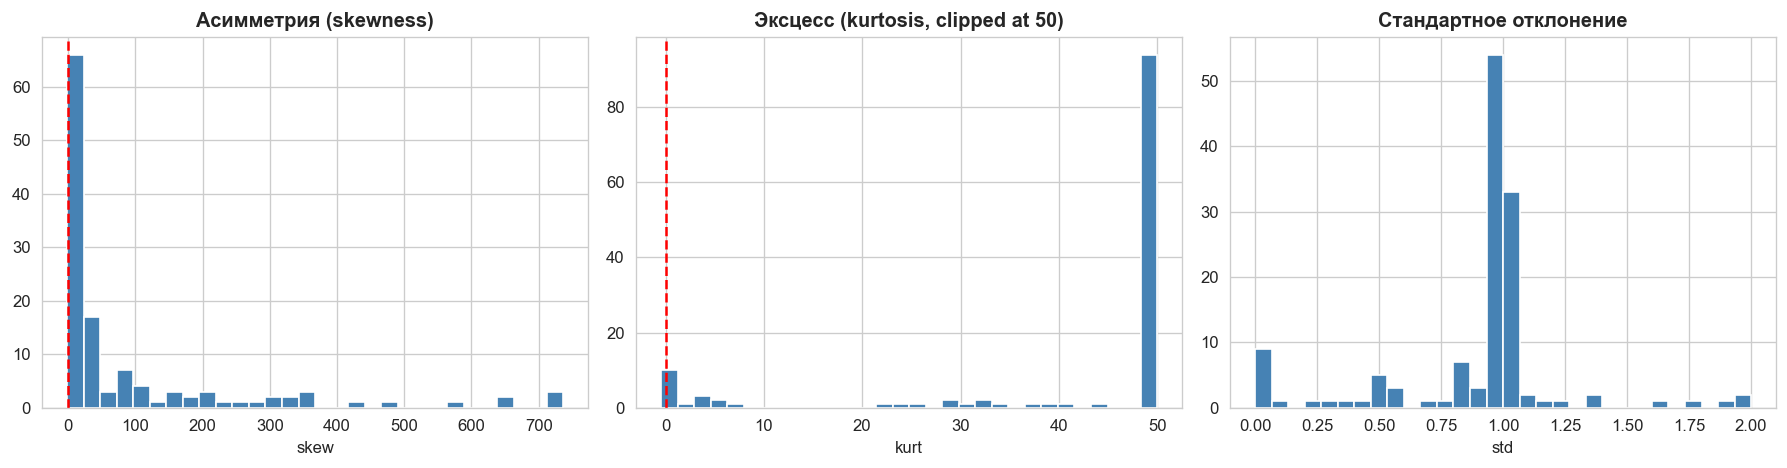

Признаков с |skew| > 3: 115
shape: (10, 8)
┌──────────────┬─────────┬──────────┬──────────┬────────────┬──────────────┬───────────┬───────────┐
│ feature      ┆ n_valid ┆ mean     ┆ std      ┆ skew       ┆ kurt         ┆ pct1      ┆ pct99     │
│ ---          ┆ ---     ┆ ---      ┆ ---      ┆ ---        ┆ ---          ┆ ---       ┆ ---       │
│ str          ┆ i64     ┆ f64      ┆ f64      ┆ f64        ┆ f64          ┆ f64       ┆ f64       │
╞══════════════╪═════════╪══════════╪══════════╪════════════╪══════════════╪═══════════╪═══════════╡
│ num_feature_ ┆ 527213  ┆ 0.0      ┆ 0.0      ┆ NaN        ┆ NaN          ┆ 0.0       ┆ 0.0       │
│ 9            ┆         ┆          ┆          ┆            ┆              ┆           ┆           │
│ num_feature_ ┆ 527213  ┆ 0.0      ┆ 0.0      ┆ NaN        ┆ NaN          ┆ 0.0       ┆ 0.0       │
│ 14           ┆         ┆          ┆          ┆            ┆              ┆           ┆           │
│ num_feature_ ┆ 60266   ┆ 0.0      ┆ 0.0      ┆

In [29]:
# Вычисляем статистики: std, skew, kurt для каждого num признака
feat_stats = []
for c in num_cols:
    vals = train[c].drop_nulls().to_numpy()
    if len(vals) < 100:
        continue
    feat_stats.append({
        'feature': c,
        'n_valid': len(vals),
        'mean': vals.mean(),
        'std': vals.std(),
        'skew': stats.skew(vals),
        'kurt': stats.kurtosis(vals),
        'pct1': np.percentile(vals, 1),
        'pct99': np.percentile(vals, 99),
    })

fs_df = pl.DataFrame(feat_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fs_df['skew'].to_numpy(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Асимметрия (skewness)', fontweight='bold')
axes[0].set_xlabel('skew')

kurt_clipped = np.clip(fs_df['kurt'].to_numpy(), -5, 50)
axes[1].hist(kurt_clipped, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Эксцесс (kurtosis, clipped at 50)', fontweight='bold')
axes[1].set_xlabel('kurt')

axes[2].hist(fs_df['std'].to_numpy(), bins=30, color='steelblue', edgecolor='white')
axes[2].set_title('Стандартное отклонение', fontweight='bold')
axes[2].set_xlabel('std')

plt.tight_layout()
plt.show()

high_skew = fs_df.filter(pl.col('skew').abs() > 3)
print(f'Признаков с |skew| > 3: {len(high_skew)}')
print(high_skew.sort('skew', descending=True).head(10))

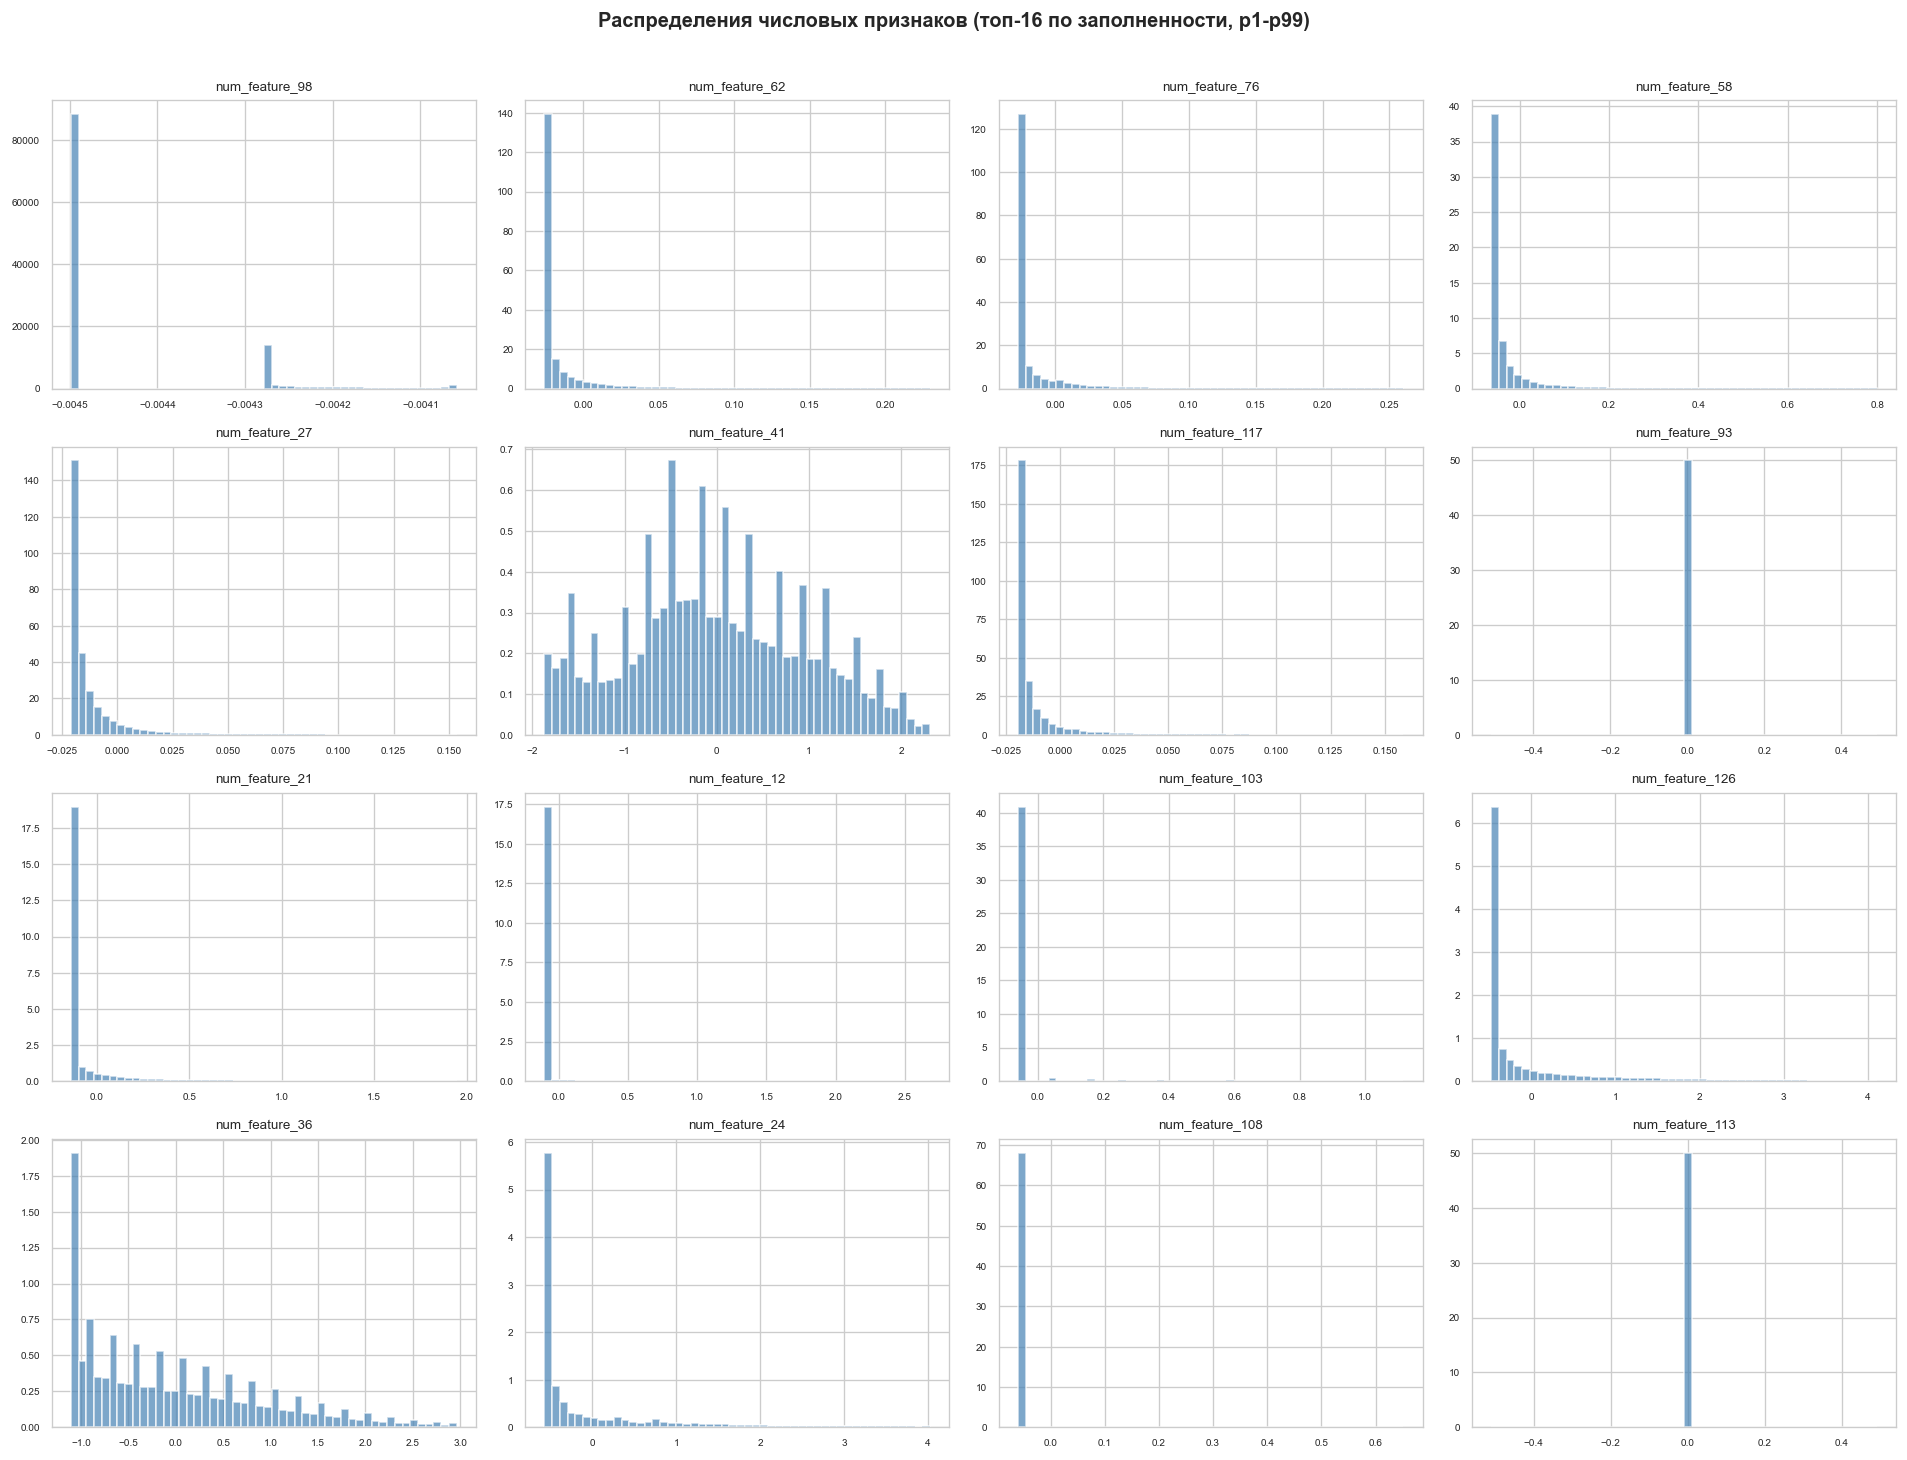

In [30]:
# Визуализация распределений топ-16 числовых признаков (с наименьшим % пропусков)
low_missing_num = (
    missing
    .filter(pl.col('feat_type') == 'numerical')
    .sort('pct_missing')
    ['col'].head(16).to_list()
)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(low_missing_num):
    vals = train[col].drop_nulls().to_numpy()
    # Ограничиваем выбросы для визуализации
    p1, p99 = np.percentile(vals, [1, 99])
    clipped = vals[(vals >= p1) & (vals <= p99)]
    axes[i].hist(clipped, bins=50, color='steelblue', alpha=0.7, density=True)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)

plt.suptitle('Распределения числовых признаков (топ-16 по заполненности, p1-p99)', 
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Анализ выбросов

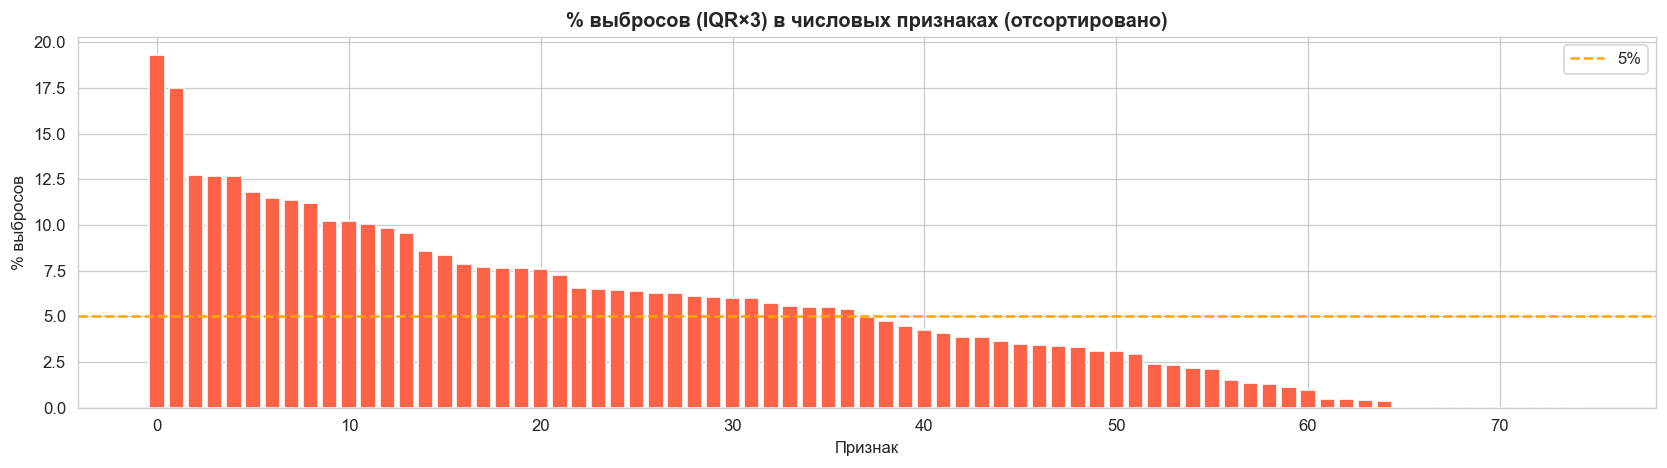

Признаков с >5% выбросов: 37
shape: (10, 2)
┌─────────────────┬──────────────┐
│ feature         ┆ pct_outliers │
│ ---             ┆ ---          │
│ str             ┆ f64          │
╞═════════════════╪══════════════╡
│ num_feature_21  ┆ 19.319098    │
│ num_feature_73  ┆ 17.4696      │
│ num_feature_51  ┆ 12.737364    │
│ num_feature_76  ┆ 12.670037    │
│ num_feature_107 ┆ 12.650873    │
│ num_feature_52  ┆ 11.816538    │
│ num_feature_94  ┆ 11.480636    │
│ num_feature_62  ┆ 11.351817    │
│ num_feature_97  ┆ 11.224405    │
│ num_feature_69  ┆ 10.214745    │
└─────────────────┴──────────────┘


In [31]:
# IQR-метод: доля выбросов в каждом числовом признаке
outlier_stats = []
for c in num_cols:
    vals = train[c].drop_nulls().to_numpy()
    if len(vals) < 100:
        continue
    q25, q75 = np.percentile(vals, [25, 75])
    iqr = q75 - q25
    if iqr == 0:
        continue
    lower, upper = q25 - 3 * iqr, q75 + 3 * iqr
    n_outliers = ((vals < lower) | (vals > upper)).sum()
    outlier_stats.append({
        'feature': c,
        'pct_outliers': n_outliers / len(vals) * 100
    })

out_df = pl.DataFrame(outlier_stats).sort('pct_outliers', descending=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(out_df)), out_df['pct_outliers'].to_numpy(), width=0.8, color='tomato')
ax.axhline(5, color='orange', ls='--', label='5%')
ax.set_title('% выбросов (IQR×3) в числовых признаках (отсортировано)', fontweight='bold')
ax.set_xlabel('Признак')
ax.set_ylabel('% выбросов')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Признаков с >5% выбросов: {(out_df["pct_outliers"] > 5).sum()}')
print(out_df.filter(pl.col('pct_outliers') > 5).head(10))

### 4.4 Корреляции между числовыми признаками

Признаков с <50% пропусков: 74
Удалено признаков с нулевой дисперсией: 5 → ['num_feature_9', 'num_feature_14', 'num_feature_32', 'num_feature_80', 'num_feature_106']
Признаков после фильтрации: 69


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


NaN в матрице корреляций: 137 → заменяем на 0
Матрица корреляций: (69, 69)


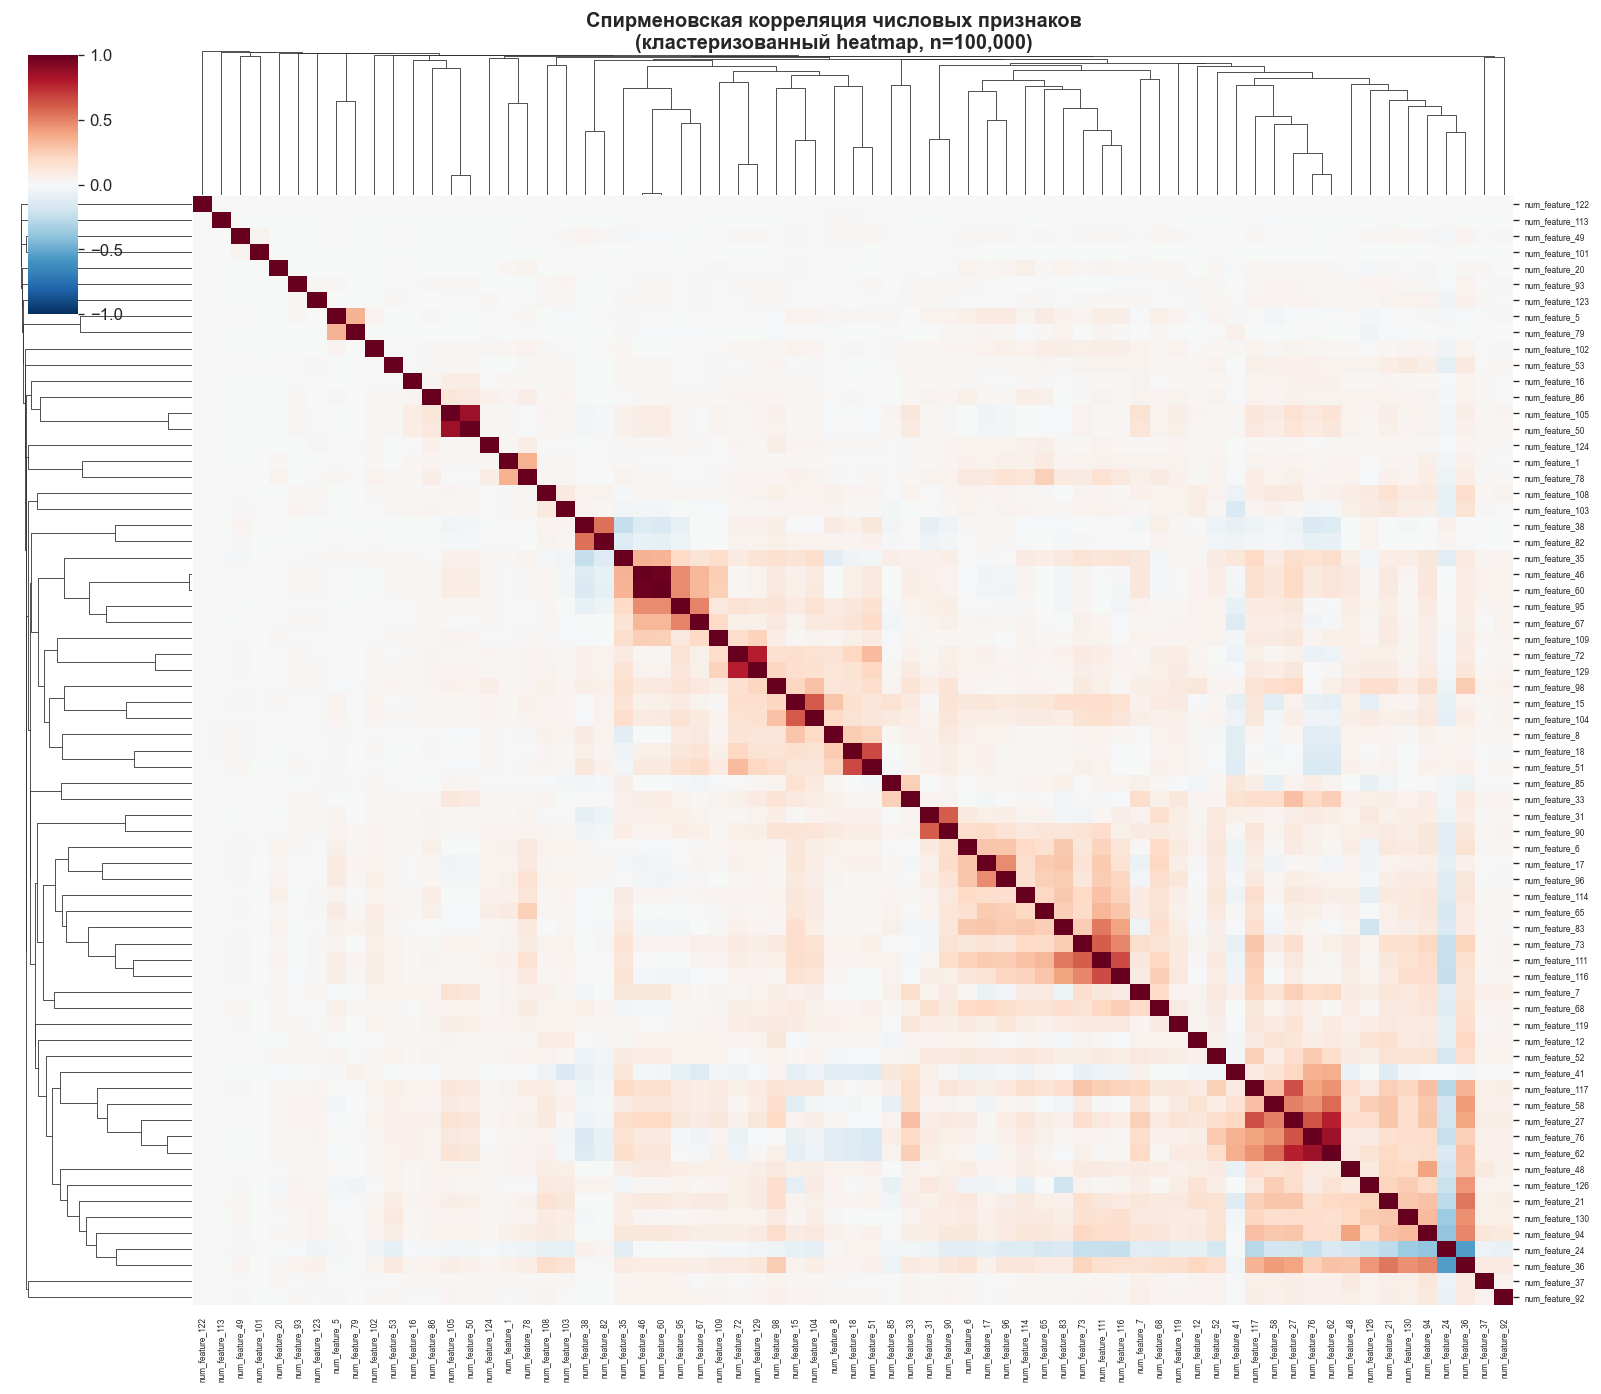

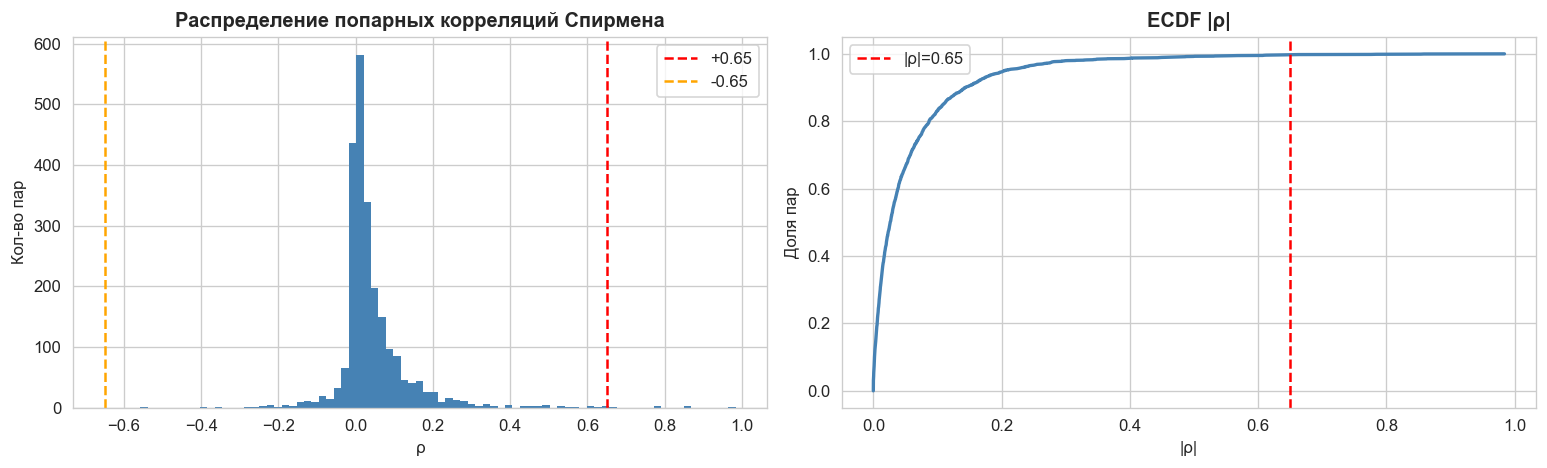


Пар с |ρ| ≥ 0.65: 7
shape: (7, 3)
┌─────────────────┬─────────────────┬────────────┐
│ feat_1          ┆ feat_2          ┆ spearman_r │
│ ---             ┆ ---             ┆ ---        │
│ str             ┆ str             ┆ f64        │
╞═════════════════╪═════════════════╪════════════╡
│ num_feature_46  ┆ num_feature_60  ┆ 0.984      │
│ num_feature_105 ┆ num_feature_50  ┆ 0.8583     │
│ num_feature_76  ┆ num_feature_62  ┆ 0.8535     │
│ num_feature_72  ┆ num_feature_129 ┆ 0.7844     │
│ num_feature_27  ┆ num_feature_62  ┆ 0.7759     │
│ num_feature_18  ┆ num_feature_51  ┆ 0.6628     │
│ num_feature_111 ┆ num_feature_116 ┆ 0.6528     │
└─────────────────┴─────────────────┴────────────┘

Число кластеров (dist < 0.3): 64
  Кластер 5 (2 признаков): ['num_feature_105', 'num_feature_50']
  Кластер 15 (2 признаков): ['num_feature_46', 'num_feature_60']
  Кластер 19 (2 признаков): ['num_feature_72', 'num_feature_129']
  Кластер 42 (3 признаков): ['num_feature_27', 'num_feature_76', 'num_fe

In [46]:
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster

# ── Параметры ────────────────────────────────────────────────────────────────
CORR_SAMPLE   = 100_000
MISSING_THRES = 50
HIGH_CORR_THR = 0.65

# ── Отбор признаков ──────────────────────────────────────────────────────────
num_complete = (
    missing
    .filter((pl.col('feat_type') == 'numerical') & (pl.col('pct_missing') < MISSING_THRES))
    ['col'].to_list()
)
print(f'Признаков с <{MISSING_THRES}% пропусков: {len(num_complete)}')

# ── Subsample ────────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
idx_corr = rng.choice(n, size=min(CORR_SAMPLE, n), replace=False)
X = train[idx_corr].select(num_complete).to_numpy().astype(np.float64)

# Заменяем NaN медианой
col_medians = np.nanmedian(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# Убираем признаки с нулевой дисперсией — они дают NaN в корреляции
nonzero_std = X.std(axis=0) > 0
removed = [c for c, keep in zip(num_complete, nonzero_std) if not keep]
if removed:
    print(f'Удалено признаков с нулевой дисперсией: {len(removed)} → {removed}')
X = X[:, nonzero_std]
num_complete = [c for c, keep in zip(num_complete, nonzero_std) if keep]
print(f'Признаков после фильтрации: {len(num_complete)}')

# ── Корреляция Спирмена ──────────────────────────────────────────────────────
corr_matrix, _ = spearmanr(X)
corr_matrix = np.clip(corr_matrix, -1, 1)

# На случай если остались NaN (очень низкая вариабельность) — заменяем 0
nan_in_corr = np.isnan(corr_matrix).sum()
if nan_in_corr > 0:
    print(f'NaN в матрице корреляций: {nan_in_corr} → заменяем на 0')
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

np.fill_diagonal(corr_matrix, 1.0)
print(f'Матрица корреляций: {corr_matrix.shape}')

# ── 1. Кластеризованный heatmap ──────────────────────────────────────────────
dist = 1 - np.abs(corr_matrix)
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2
dist = np.clip(dist, 0, None)   # убираем отрицательные значения из-за float погрешности

condensed = dist[np.triu_indices(len(num_complete), k=1)]
link = linkage(condensed, method='average')
cluster_labels = fcluster(link, t=0.3, criterion='distance')

g = sns.clustermap(
    corr_matrix,
    row_linkage=link,
    col_linkage=link,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    figsize=(14, 12),
    xticklabels=num_complete,
    yticklabels=num_complete,
    dendrogram_ratio=0.12,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=5, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=5, rotation=0)
g.figure.suptitle(
    f'Спирменовская корреляция числовых признаков\n(кластеризованный heatmap, n={CORR_SAMPLE:,})',
    y=1.01, fontsize=12, fontweight='bold'
)
plt.show()

# ── 2. Распределение значений корреляции ─────────────────────────────────────
upper = corr_matrix[np.triu_indices(len(num_complete), k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(upper, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline( HIGH_CORR_THR, color='red',    ls='--', label=f'+{HIGH_CORR_THR}')
axes[0].axvline(-HIGH_CORR_THR, color='orange', ls='--', label=f'-{HIGH_CORR_THR}')
axes[0].set_title('Распределение попарных корреляций Спирмена', fontweight='bold')
axes[0].set_xlabel('ρ')
axes[0].set_ylabel('Кол-во пар')
axes[0].legend()

abs_sorted = np.sort(np.abs(upper))
axes[1].plot(abs_sorted, np.linspace(0, 1, len(abs_sorted)), lw=2, color='steelblue')
axes[1].axvline(HIGH_CORR_THR, color='red', ls='--', label=f'|ρ|={HIGH_CORR_THR}')
axes[1].set_title('ECDF |ρ|', fontweight='bold')
axes[1].set_xlabel('|ρ|')
axes[1].set_ylabel('Доля пар')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 3. Таблица высококоррелированных пар ─────────────────────────────────────
rows = [
    {'feat_1': num_complete[i], 'feat_2': num_complete[j], 'spearman_r': round(corr_matrix[i, j], 4)}
    for i in range(len(num_complete))
    for j in range(i + 1, len(num_complete))
    if abs(corr_matrix[i, j]) >= HIGH_CORR_THR
]

high_corr = (
    pl.DataFrame(rows).sort('spearman_r', descending=True)
    if rows
    else pl.DataFrame({'feat_1': [], 'feat_2': [], 'spearman_r': []})
)

print(f'\nПар с |ρ| ≥ {HIGH_CORR_THR}: {len(high_corr)}')
print(high_corr.head(20))

# ── 4. Кластеры признаков ────────────────────────────────────────────────────
n_clusters = cluster_labels.max()
print(f'\nЧисло кластеров (dist < 0.3): {n_clusters}')
for cid in range(1, n_clusters + 1):
    members = [f for f, c in zip(num_complete, cluster_labels) if c == cid]
    if len(members) > 1:
        print(f'  Кластер {cid} ({len(members)} признаков): {members[:8]}{" ..." if len(members) > 8 else ""}')

In [48]:
from collections import defaultdict

# ── Собираем кластеры с 2+ признаками ────────────────────────────────────────
cluster_to_feats = defaultdict(list)
for feat, cid in zip(num_complete, cluster_labels):
    cluster_to_feats[cid].append(feat)

multi_clusters = {cid: feats for cid, feats in cluster_to_feats.items() if len(feats) > 1}
print(f'Кластеров для агрегации: {len(multi_clusters)}')
for cid, feats in sorted(multi_clusters.items()):
    print(f'  cluster_{cid}: {feats}')

# ── Функция агрегации одного датасета ────────────────────────────────────────
def aggregate_clusters(df: pl.DataFrame, clusters: dict, drop_originals: bool = False) -> pl.DataFrame:
    new_cols = []
    cols_to_drop = []

    for cid, feats in sorted(clusters.items()):
        prefix = f'cluster_{cid}'

        mean_expr  = pl.mean_horizontal(*[pl.col(f) for f in feats])
        min_expr   = pl.min_horizontal(*[pl.col(f) for f in feats])
        max_expr   = pl.max_horizontal(*[pl.col(f) for f in feats])
        # std = sqrt(E[x²] - E[x]²)  — популяционное стандартное отклонение
        mean_sq    = pl.mean_horizontal(*[pl.col(f) ** 2 for f in feats])
        std_expr   = (mean_sq - mean_expr ** 2).sqrt()

        new_cols += [
            mean_expr.alias(f'{prefix}_mean'),
            std_expr.alias(f'{prefix}_std'),
            min_expr.alias(f'{prefix}_min'),
            max_expr.alias(f'{prefix}_max'),
            (max_expr - min_expr).alias(f'{prefix}_range'),
            pl.sum_horizontal(*[pl.col(f).is_null().cast(pl.Int8) for f in feats])
              .alias(f'{prefix}_n_null'),
        ]

        if drop_originals:
            cols_to_drop += feats

    result = df.with_columns(new_cols)

    if drop_originals and cols_to_drop:
        result = result.drop(cols_to_drop)

    return result

# ── Применяем к train и test ──────────────────────────────────────────────────
train_agg = aggregate_clusters(train, multi_clusters, drop_originals=False)
test_agg  = aggregate_clusters(test,  multi_clusters, drop_originals=False)

new_feat_names = [
    f'cluster_{cid}_{agg}'
    for cid in sorted(multi_clusters)
    for agg in ('mean', 'std', 'min', 'max', 'range', 'n_null')
]

print(f'\nДобавлено признаков: {len(new_feat_names)}')
print(f'Train: {train.shape} → {train_agg.shape}')
print(f'Test:  {test.shape}  → {test_agg.shape}')

# ── Проверка NaN ─────────────────────────────────────────────────────────────
null_check = (
    train_agg.select(new_feat_names)
    .null_count()
    .unpivot(variable_name='feature', value_name='n_null')
    .filter(pl.col('n_null') > 0)
    .sort('n_null', descending=True)
)
print(f'\nНовых признаков с пропусками: {len(null_check)}')
print(null_check.head(10))

print('\nПревью:')
print(train_agg.select(['customer_id'] + new_feat_names[:12]).head(5))

Кластеров для агрегации: 4
  cluster_5: ['num_feature_105', 'num_feature_50']
  cluster_15: ['num_feature_46', 'num_feature_60']
  cluster_19: ['num_feature_72', 'num_feature_129']
  cluster_42: ['num_feature_27', 'num_feature_76', 'num_feature_62']

Добавлено признаков: 24
Train: (750000, 200) → (750000, 224)
Test:  (250000, 200)  → (250000, 224)

Новых признаков с пропусками: 20
shape: (10, 2)
┌──────────────────┬────────┐
│ feature          ┆ n_null │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ cluster_5_mean   ┆ 333829 │
│ cluster_5_std    ┆ 333829 │
│ cluster_5_min    ┆ 333829 │
│ cluster_5_max    ┆ 333829 │
│ cluster_5_range  ┆ 333829 │
│ cluster_19_mean  ┆ 252042 │
│ cluster_19_std   ┆ 252042 │
│ cluster_19_min   ┆ 252042 │
│ cluster_19_max   ┆ 252042 │
│ cluster_19_range ┆ 252042 │
└──────────────────┴────────┘

Превью:
shape: (5, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬────────

### 4.5 Pairplot топовых числовых признаков

Признаки для pairplot: ['num_feature_98', 'num_feature_62', 'num_feature_76', 'num_feature_58', 'num_feature_27', 'num_feature_41', 'num_feature_117']
Таргет для раскраски: target_10_1  (prevalence=0.315)


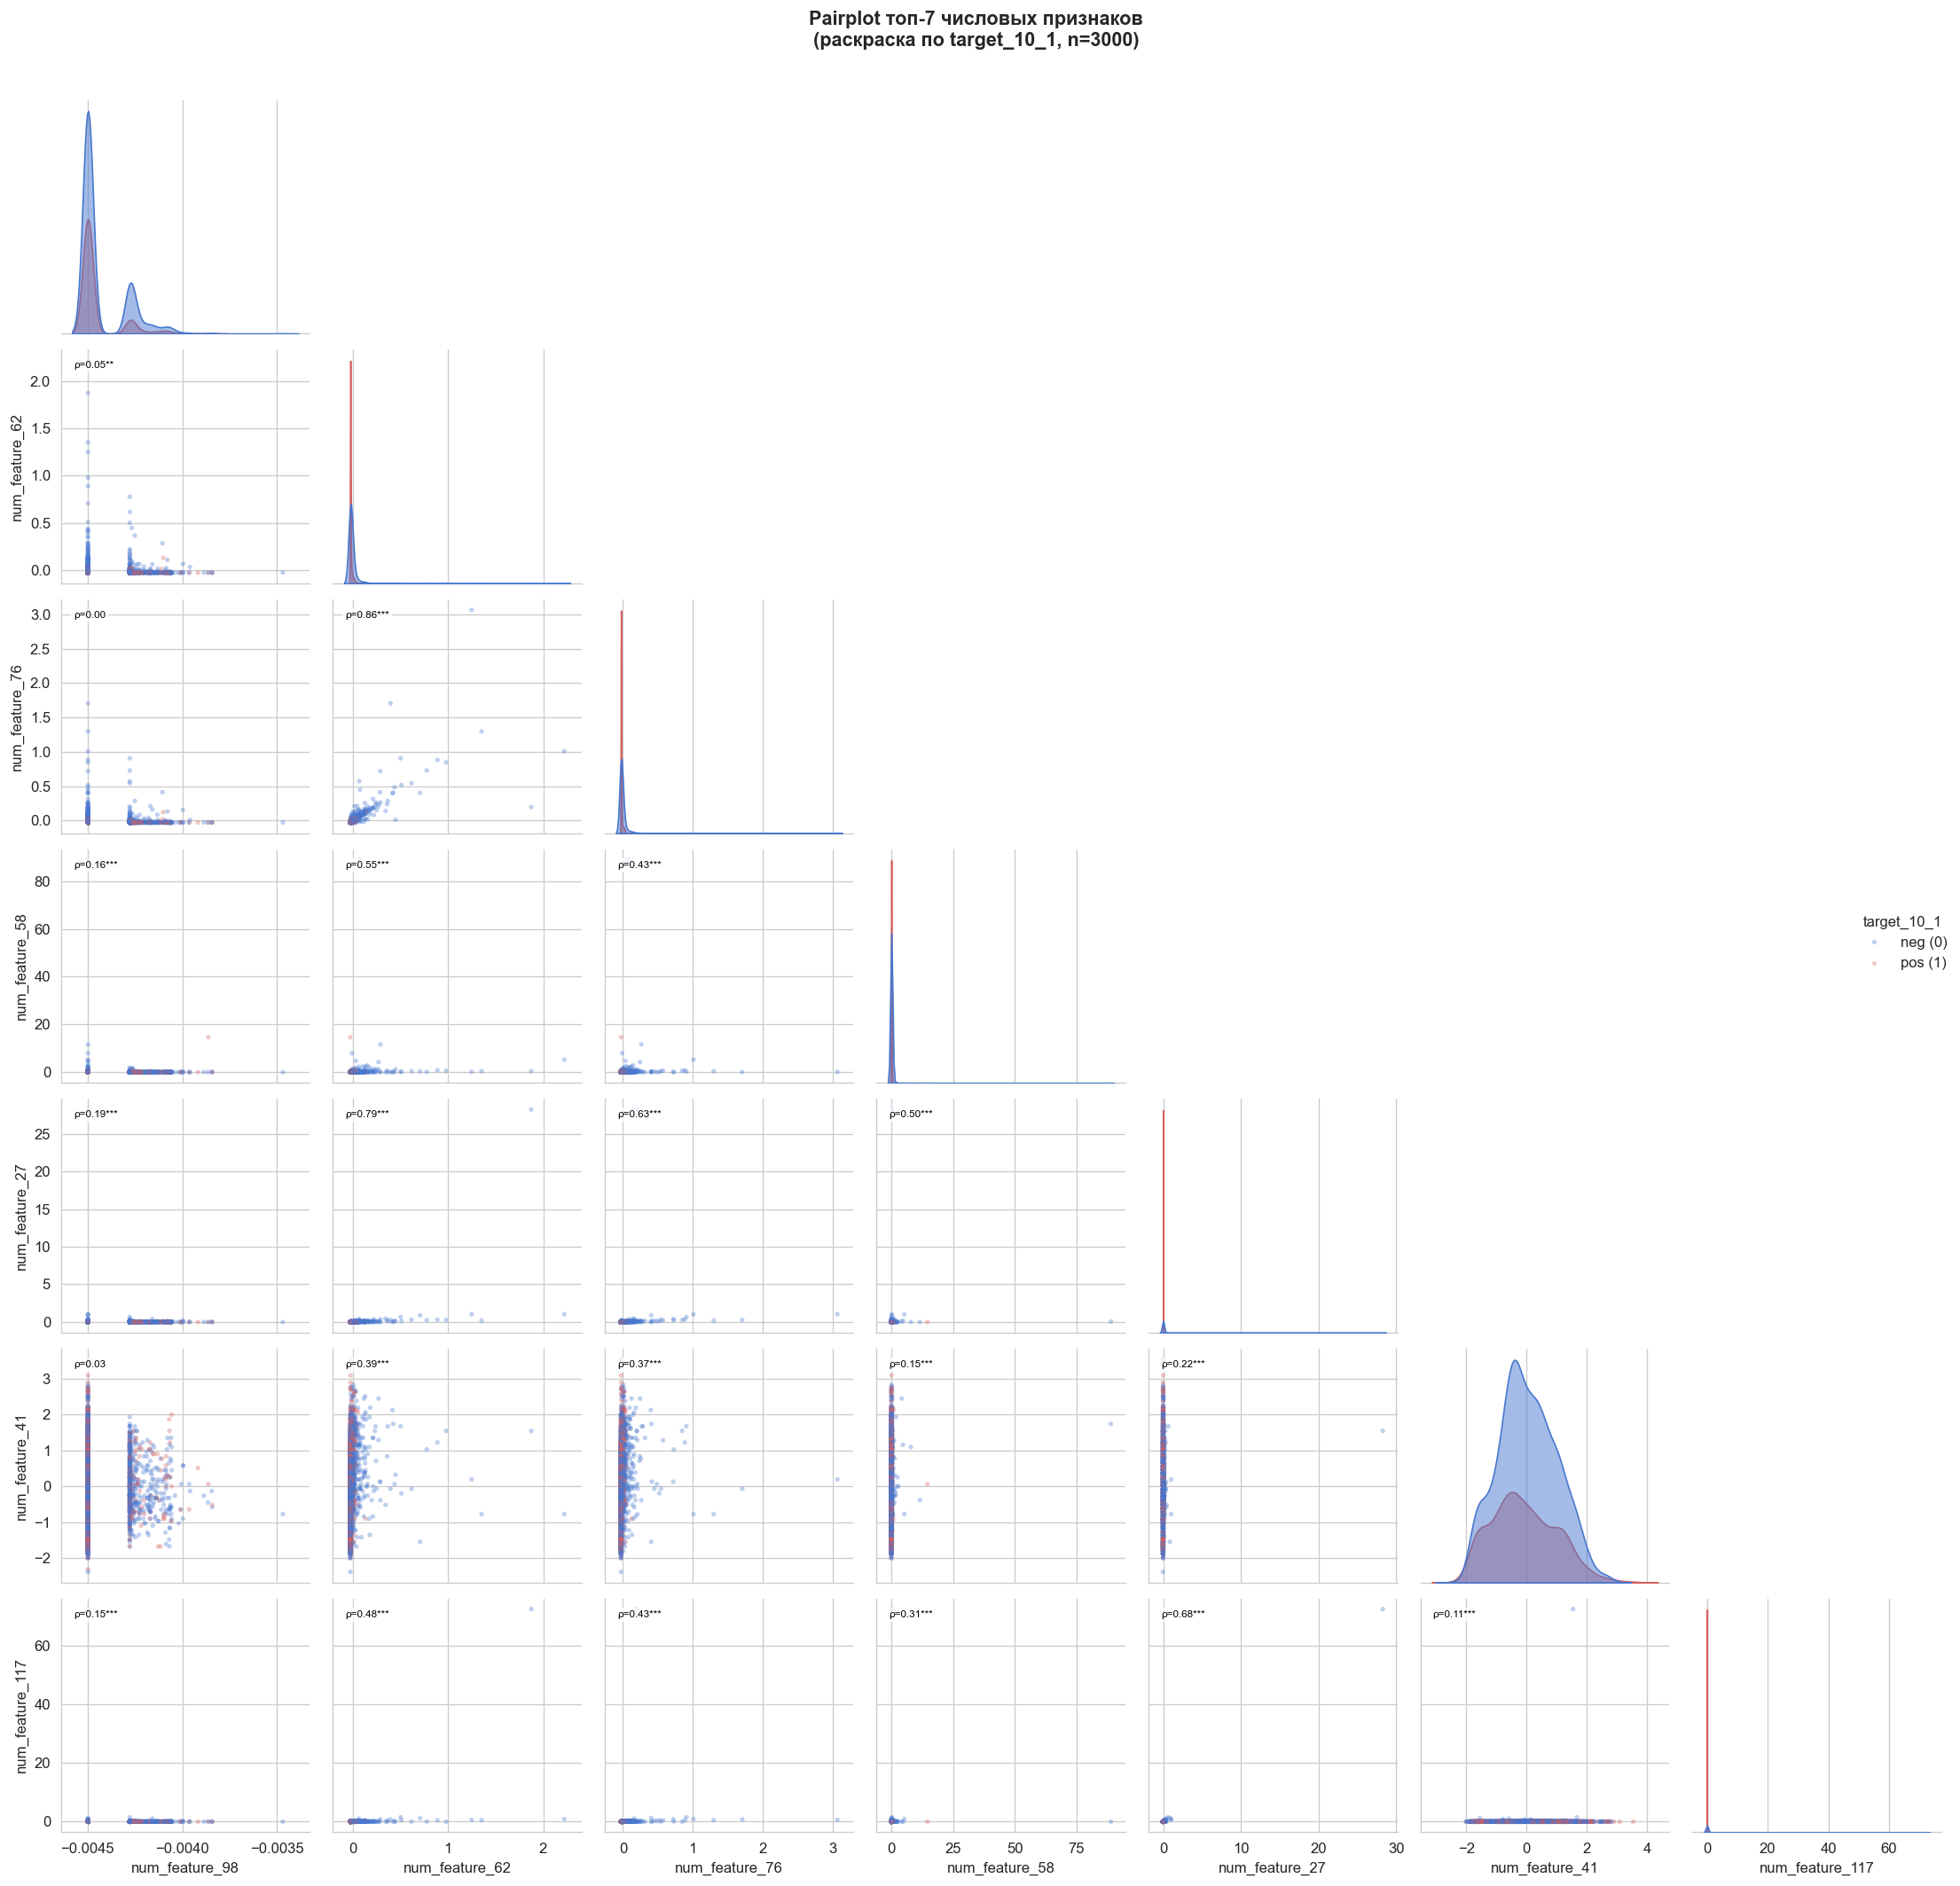

In [43]:
import pandas as pd

# --- Отбор признаков ---
# Берём топ-7 числовых по наименьшему % пропусков среди num_complete
pairplot_cols = (
    missing
    .filter(pl.col('feat_type') == 'numerical')
    .sort('pct_missing')
    ['col'].head(7).to_list()
)

# Выбираем наиболее сбалансированный таргет (ближайший к 50%) для раскраски
target_means_pp = np.array([target[tc].mean() for tc in target_cols])
best_target_idx = int(np.argmin(np.abs(target_means_pp - 0.5)))
color_target = target_cols[best_target_idx]
print(f'Признаки для pairplot: {pairplot_cols}')
print(f'Таргет для раскраски: {color_target}  (prevalence={target_means_pp[best_target_idx]:.3f})')

# --- Subsample ---
SAMPLE_PP = 3000
pp_idx = np.random.choice(n, size=SAMPLE_PP, replace=False)

pp_df = (
    train[pp_idx]
    .select(pairplot_cols)
    .with_columns(
        target[pp_idx][color_target].cast(pl.Utf8).alias(color_target)
    )
    .to_pandas()
)

# Удаляем строки где таргет NaN (на всякий случай)
pp_df = pp_df.dropna(subset=[color_target])
pp_df[color_target] = pp_df[color_target].map({'0.0': 'neg (0)', '1.0': 'pos (1)'})

# --- Pairplot ---
palette = {'neg (0)': '#4878CF', 'pos (1)': '#D65F5F'}

g = sns.pairplot(
    pp_df,
    hue=color_target,
    palette=palette,
    diag_kind='kde',          # KDE на диагонали
    plot_kws=dict(alpha=0.35, s=10, linewidth=0),
    diag_kws=dict(fill=True, alpha=0.5),
    corner=True,              # только нижний треугольник — быстрее и читаемее
)

g.figure.suptitle(
    f'Pairplot топ-7 числовых признаков\n(раскраска по {color_target}, n={SAMPLE_PP})',
    y=1.01, fontsize=13, fontweight='bold'
)

# Добавляем корреляцию Спирмена в каждый subplot нижнего треугольника
from scipy.stats import spearmanr
for i in range(len(pairplot_cols)):
    for j in range(i):
        ax = g.axes[i][j]
        x = pp_df[pairplot_cols[j]].dropna()
        y = pp_df[pairplot_cols[i]].dropna()
        common = pp_df[[pairplot_cols[j], pairplot_cols[i]]].dropna()
        if len(common) > 10:
            r, pv = spearmanr(common.iloc[:, 0], common.iloc[:, 1])
            stars = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''
            ax.annotate(
                f'ρ={r:.2f}{stars}',
                xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=7, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
            )

plt.tight_layout()
plt.show()

## 5. Связь признаков с таргетами

### 5.1 Важность числовых признаков (point-biserial корреляция)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5546: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


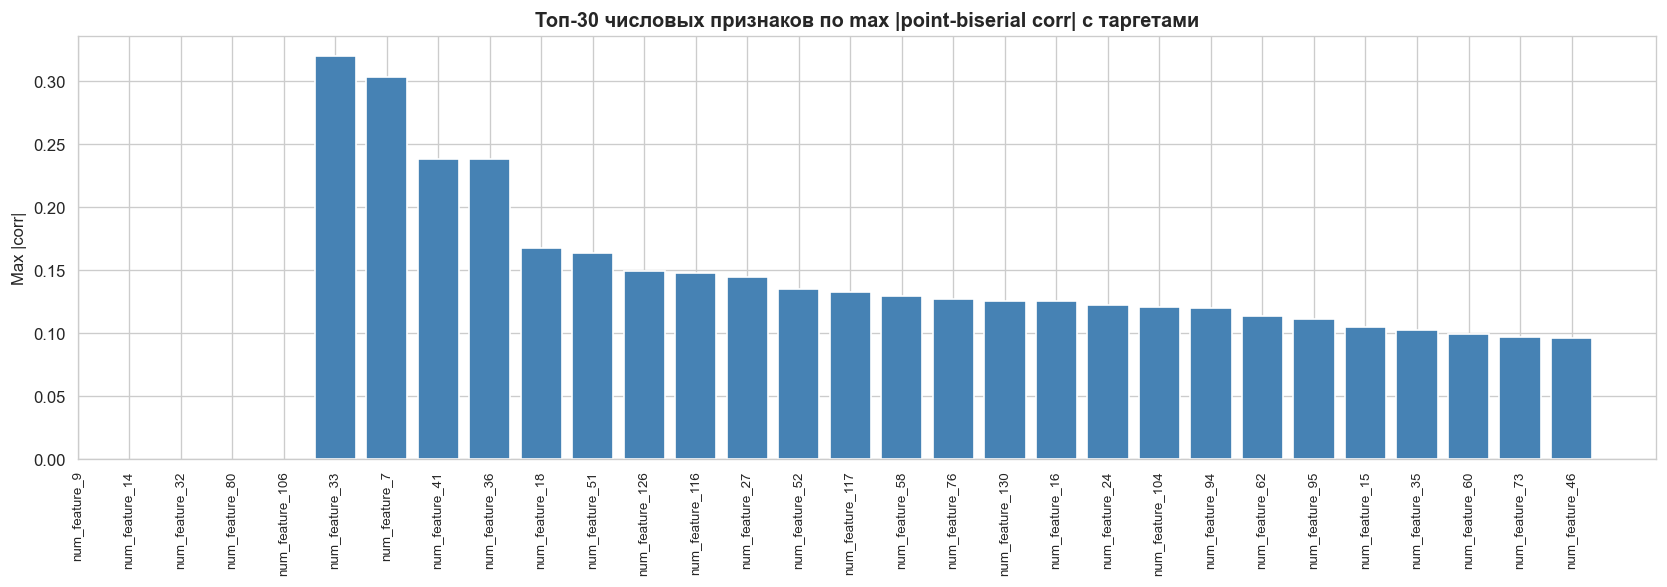

Топ-15 признаков:
shape: (15, 2)
┌─────────────────┬──────────────┐
│ feature         ┆ max_abs_corr │
│ ---             ┆ ---          │
│ str             ┆ f64          │
╞═════════════════╪══════════════╡
│ num_feature_9   ┆ NaN          │
│ num_feature_14  ┆ NaN          │
│ num_feature_32  ┆ NaN          │
│ num_feature_80  ┆ NaN          │
│ num_feature_106 ┆ NaN          │
│ …               ┆ …            │
│ num_feature_51  ┆ 0.163532     │
│ num_feature_126 ┆ 0.149525     │
│ num_feature_116 ┆ 0.147715     │
│ num_feature_27  ┆ 0.144395     │
│ num_feature_52  ┆ 0.134684     │
└─────────────────┴──────────────┘


In [33]:
from scipy.stats import pointbiserialr

# Для первых 10 таргетов считаем max |corr| с числовыми признаками
# (proxy для feature importance)
sample_n = min(30000, n)
idx = np.random.choice(n, size=sample_n, replace=False)

feat_target_corr = np.zeros((len(num_complete), len(target_cols)))

target_np = target.select(target_cols).to_numpy()[idx]

for fi, feat in enumerate(num_complete):
    x = train[feat].to_numpy()[idx]
    x_mean = np.nanmean(x)
    x_filled = np.where(np.isnan(x), x_mean, x)
    for ti in range(len(target_cols)):
        y = target_np[:, ti]
        valid = ~np.isnan(y)
        if valid.sum() < 100:
            continue
        try:
            r, _ = pointbiserialr(y[valid], x_filled[valid])
            feat_target_corr[fi, ti] = r
        except:
            pass

# Max abs corr по всем таргетам для каждого признака
max_corr = np.abs(feat_target_corr).max(axis=1)
feat_importance_df = pl.DataFrame({
    'feature': num_complete,
    'max_abs_corr': max_corr.tolist()
}).sort('max_abs_corr', descending=True)

fig, ax = plt.subplots(figsize=(14, 5))
top30 = feat_importance_df.head(30)
ax.bar(range(30), top30['max_abs_corr'].to_numpy(), color='steelblue')
ax.set_xticks(range(30))
ax.set_xticklabels(top30['feature'].to_list(), rotation=90, fontsize=8)
ax.set_title('Топ-30 числовых признаков по max |point-biserial corr| с таргетами', fontweight='bold')
ax.set_ylabel('Max |corr|')
plt.tight_layout()
plt.show()

print('Топ-15 признаков:')
print(feat_importance_df.head(15))

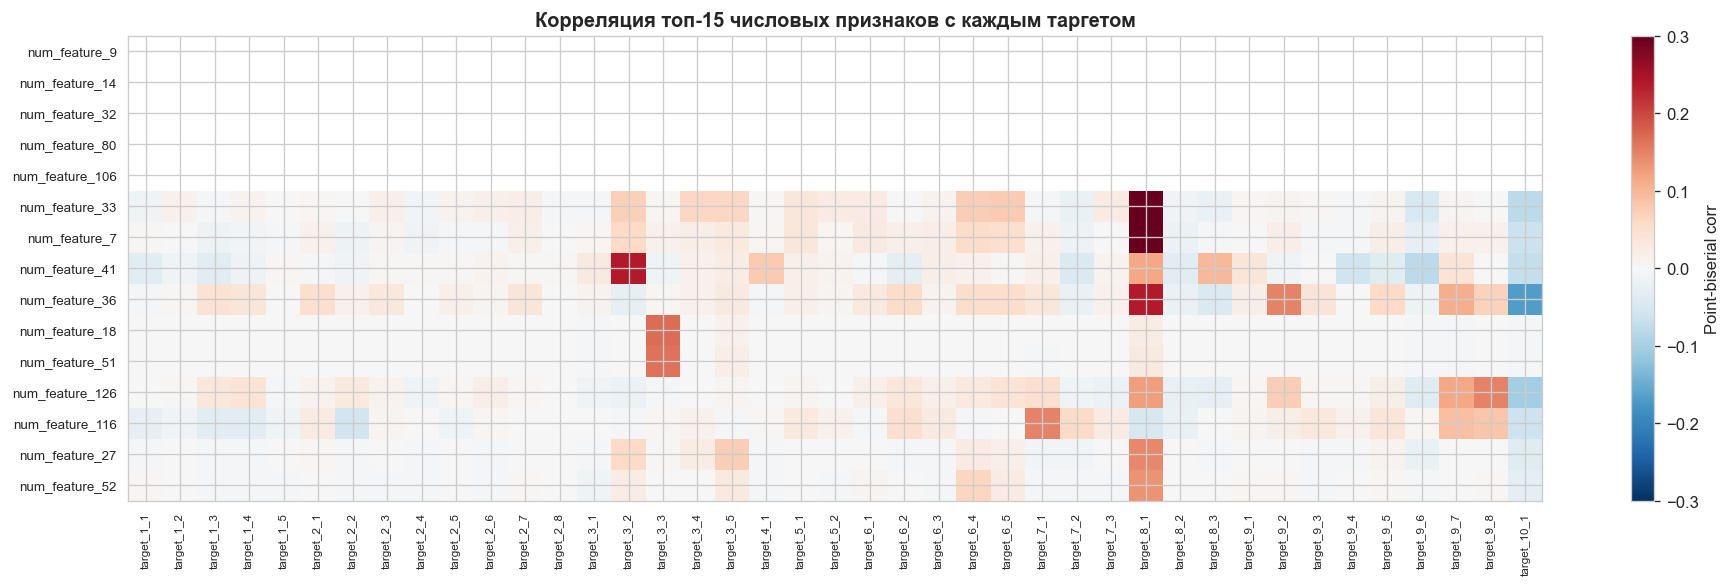

In [34]:
# Heatmap: признак × таргет
top15_feats = feat_importance_df.head(15)['feature'].to_list()
feat_idx = [num_complete.index(f) for f in top15_feats]

sub_matrix = feat_target_corr[feat_idx, :]

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(sub_matrix, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
plt.colorbar(im, ax=ax, label='Point-biserial corr')
ax.set_xticks(range(len(target_cols)))
ax.set_yticks(range(len(top15_feats)))
ax.set_xticklabels(target_cols, rotation=90, fontsize=7)
ax.set_yticklabels(top15_feats, fontsize=8)
ax.set_title('Корреляция топ-15 числовых признаков с каждым таргетом', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Важность категориальных признаков (Cramér's V с таргетами)

Выбранные таргеты для анализа: ['target_10_1', 'target_9_6', 'target_8_1', 'target_3_1', 'target_3_2']
Их prevalence: [0.315, 0.223, 0.102, 0.098, 0.097]


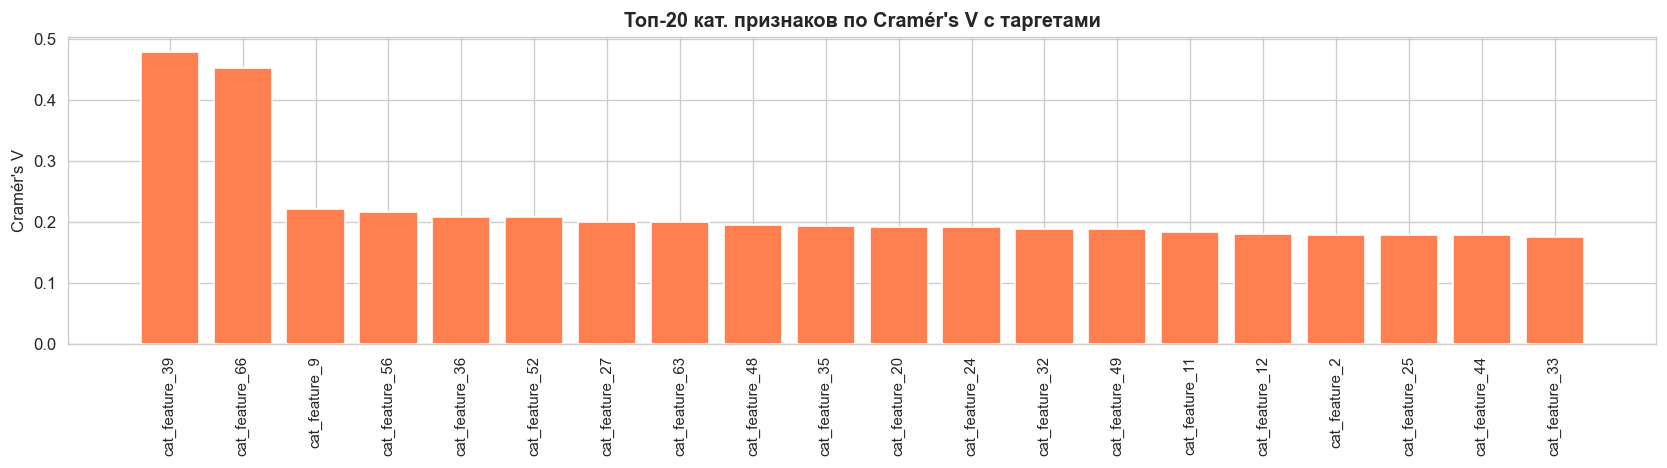

Топ-10 категориальных признаков:
shape: (10, 2)
┌────────────────┬───────────────┐
│ feature        ┆ max_cramers_v │
│ ---            ┆ ---           │
│ str            ┆ f64           │
╞════════════════╪═══════════════╡
│ cat_feature_39 ┆ 0.479438      │
│ cat_feature_66 ┆ 0.453159      │
│ cat_feature_9  ┆ 0.222142      │
│ cat_feature_56 ┆ 0.216058      │
│ cat_feature_36 ┆ 0.208735      │
│ cat_feature_52 ┆ 0.208246      │
│ cat_feature_27 ┆ 0.200088      │
│ cat_feature_63 ┆ 0.200088      │
│ cat_feature_48 ┆ 0.194737      │
│ cat_feature_35 ┆ 0.19354       │
└────────────────┴───────────────┘


In [35]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Cramér's V — мера связи категориального признака с бинарным таргетом."""
    ct = np.zeros((len(np.unique(x[~np.isnan(x.astype(float))])), 2))
    x_vals = x[~np.isnan(x.astype(float))]
    y_vals = y[~np.isnan(x.astype(float))]
    uniq = np.unique(x_vals)
    for i, v in enumerate(uniq):
        mask = x_vals == v
        ct[i, 0] = (y_vals[mask] == 0).sum()
        ct[i, 1] = (y_vals[mask] == 1).sum()
    if ct.sum() == 0:
        return 0
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if min(ct.shape) > 1 else 0

# Для топ-5 таргетов по балансу (ближе к 50%) считаем Cramér's V
target_means_arr = np.array([target[tc].mean() for tc in target_cols])
balanced_targets_idx = np.argsort(np.abs(target_means_arr - 0.5))[:5]
balanced_targets = [target_cols[i] for i in balanced_targets_idx]

print(f'Выбранные таргеты для анализа: {balanced_targets}')
print(f'Их prevalence: {[round(target_means_arr[i], 3) for i in balanced_targets_idx]}')

# Subsample
sample_idx2 = np.random.choice(n, size=20000, replace=False)
target_sample = target.select(balanced_targets).to_numpy()[sample_idx2]

cv_results = []
for ci, cat in enumerate(cat_cols):
    x_cat = train[cat].to_numpy()[sample_idx2].astype(float)
    max_cv = 0
    for ti, tcol in enumerate(balanced_targets):
        y = target_sample[:, ti]
        cv = cramers_v(x_cat, y)
        max_cv = max(max_cv, cv)
    cv_results.append({'feature': cat, 'max_cramers_v': max_cv})

cv_df = pl.DataFrame(cv_results).sort('max_cramers_v', descending=True)

fig, ax = plt.subplots(figsize=(14, 4))
top20_cat = cv_df.head(20)
ax.bar(range(20), top20_cat['max_cramers_v'].to_numpy(), color='coral')
ax.set_xticks(range(20))
ax.set_xticklabels(top20_cat['feature'].to_list(), rotation=90, fontsize=9)
ax.set_title('Топ-20 кат. признаков по Cramér\'s V с таргетами', fontweight='bold')
ax.set_ylabel("Cramér's V")
plt.tight_layout()
plt.show()

print('Топ-10 категориальных признаков:')
print(cv_df.head(10))

### 5.3 Анализ дисбаланса таргетов

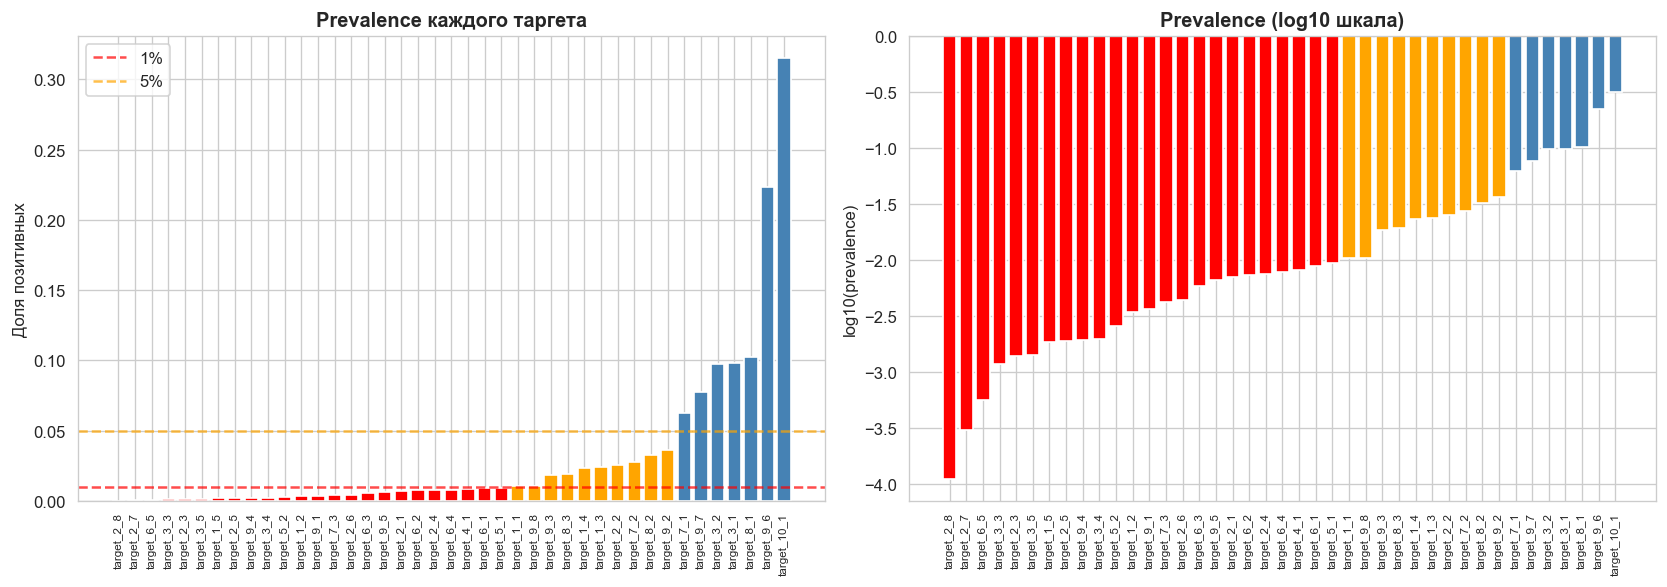

Редких таргетов (<1%): 24
  target_2_8: 0.011%
  target_2_7: 0.03%
  target_6_5: 0.056%
  target_3_3: 0.119%
  target_2_3: 0.139%
  target_3_5: 0.142%
  target_1_5: 0.184%
  target_2_5: 0.189%
  target_9_4: 0.194%
  target_3_4: 0.195%
  target_5_2: 0.256%
  target_1_2: 0.343%
  target_9_1: 0.363%
  target_7_3: 0.425%
  target_2_6: 0.441%
  target_6_3: 0.581%
  target_9_5: 0.658%
  target_2_1: 0.709%
  target_6_2: 0.739%
  target_2_4: 0.757%
  target_6_4: 0.785%
  target_4_1: 0.813%
  target_6_1: 0.883%
  target_5_1: 0.934%


In [36]:
prevalence = np.array([target[tc].mean() for tc in target_cols])
sorted_idx = np.argsort(prevalence)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барчарт prevalence
colors = ['red' if p < 0.01 else 'orange' if p < 0.05 else 'steelblue' for p in prevalence[sorted_idx]]
axes[0].bar(range(len(target_cols)), prevalence[sorted_idx], color=colors)
axes[0].axhline(0.01, color='red', ls='--', alpha=0.7, label='1%')
axes[0].axhline(0.05, color='orange', ls='--', alpha=0.7, label='5%')
axes[0].set_xticks(range(len(target_cols)))
axes[0].set_xticklabels([target_cols[i] for i in sorted_idx], rotation=90, fontsize=7)
axes[0].set_title('Prevalence каждого таргета', fontweight='bold')
axes[0].set_ylabel('Доля позитивных')
axes[0].legend()

# Логарифмическая шкала
axes[1].bar(range(len(target_cols)), np.log10(prevalence[sorted_idx] + 1e-6), color=colors)
axes[1].set_xticks(range(len(target_cols)))
axes[1].set_xticklabels([target_cols[i] for i in sorted_idx], rotation=90, fontsize=7)
axes[1].set_title('Prevalence (log10 шкала)', fontweight='bold')
axes[1].set_ylabel('log10(prevalence)')

plt.tight_layout()
plt.show()

rare = [(target_cols[i], round(prevalence[i]*100, 3)) for i in range(len(target_cols)) if prevalence[i] < 0.01]
print(f'Редких таргетов (<1%): {len(rare)}')
for t, p in sorted(rare, key=lambda x: x[1]):
    print(f'  {t}: {p}%')

## 6. Covariate Shift: Train vs Test

Метрика KS-статистика для числовых признаков.

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


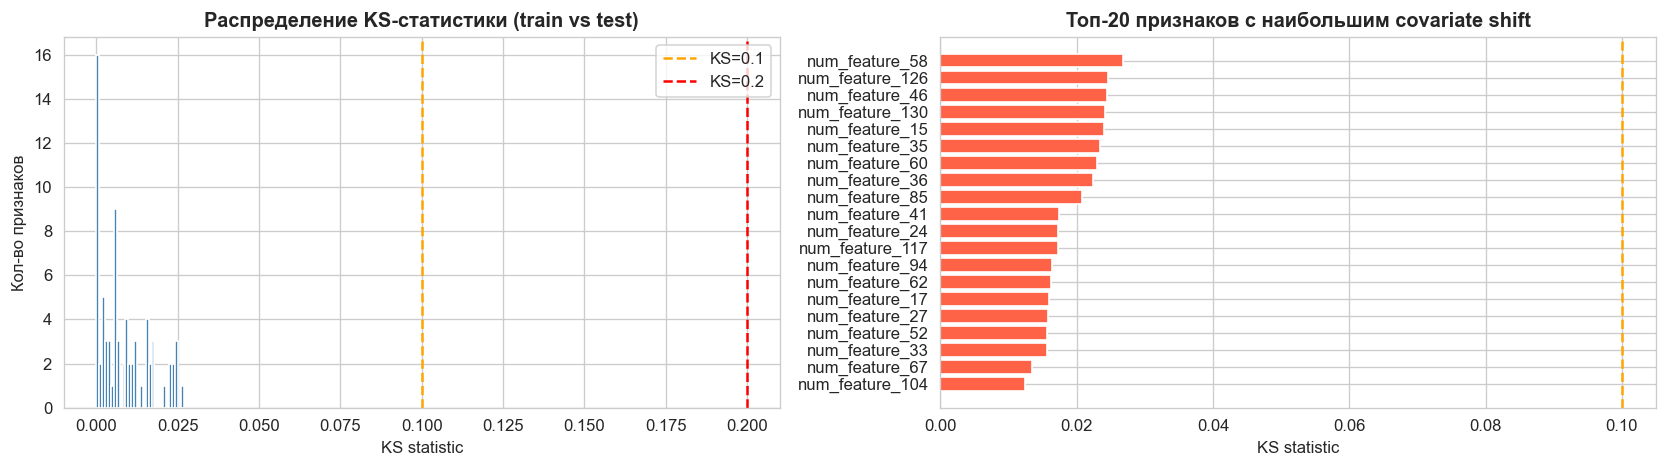

Признаков с KS > 0.1: 0
Признаков с KS > 0.2: 0

Топ-10 сдвинутых признаков:
shape: (10, 3)
┌─────────────────┬─────────┬──────────┐
│ feature         ┆ ks_stat ┆ p_value  │
│ ---             ┆ ---     ┆ ---      │
│ str             ┆ f64     ┆ f64      │
╞═════════════════╪═════════╪══════════╡
│ num_feature_58  ┆ 0.0268  ┆ 0.055125 │
│ num_feature_126 ┆ 0.0246  ┆ 0.097027 │
│ num_feature_46  ┆ 0.0244  ┆ 0.101898 │
│ num_feature_130 ┆ 0.0242  ┆ 0.106971 │
│ num_feature_15  ┆ 0.024   ┆ 0.112251 │
│ num_feature_35  ┆ 0.0234  ┆ 0.129393 │
│ num_feature_60  ┆ 0.023   ┆ 0.141964 │
│ num_feature_36  ┆ 0.0224  ┆ 0.162651 │
│ num_feature_85  ┆ 0.0208  ┆ 0.229579 │
│ num_feature_41  ┆ 0.0174  ┆ 0.435491 │
└─────────────────┴─────────┴──────────┘


In [37]:
ks_results = []
for col in num_complete:
    train_vals = train[col].drop_nulls().to_numpy()
    test_vals  = test[col].drop_nulls().to_numpy()
    if len(train_vals) < 100 or len(test_vals) < 100:
        continue
    # Subsample для скорости
    tr_s = train_vals[np.random.choice(len(train_vals), size=min(5000, len(train_vals)), replace=False)]
    te_s = test_vals[np.random.choice(len(test_vals), size=min(5000, len(test_vals)), replace=False)]
    ks_stat, p_val = ks_2samp(tr_s, te_s)
    ks_results.append({'feature': col, 'ks_stat': ks_stat, 'p_value': p_val})

ks_df = pl.DataFrame(ks_results).sort('ks_stat', descending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ks_vals = ks_df['ks_stat'].to_numpy()
axes[0].hist(ks_vals, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0.1, color='orange', ls='--', label='KS=0.1')
axes[0].axvline(0.2, color='red', ls='--', label='KS=0.2')
axes[0].set_title('Распределение KS-статистики (train vs test)', fontweight='bold')
axes[0].set_xlabel('KS statistic')
axes[0].set_ylabel('Кол-во признаков')
axes[0].legend()

top20_ks = ks_df.head(20)
axes[1].barh(top20_ks['feature'].to_list()[::-1], top20_ks['ks_stat'].to_numpy()[::-1], color='tomato')
axes[1].axvline(0.1, color='orange', ls='--')
axes[1].set_title('Топ-20 признаков с наибольшим covariate shift', fontweight='bold')
axes[1].set_xlabel('KS statistic')

plt.tight_layout()
plt.show()

shifted = ks_df.filter(pl.col('ks_stat') > 0.1)
print(f'Признаков с KS > 0.1: {len(shifted)}')
print(f'Признаков с KS > 0.2: {len(ks_df.filter(pl.col("ks_stat") > 0.2))}')
print('\nТоп-10 сдвинутых признаков:')
print(ks_df.head(10))

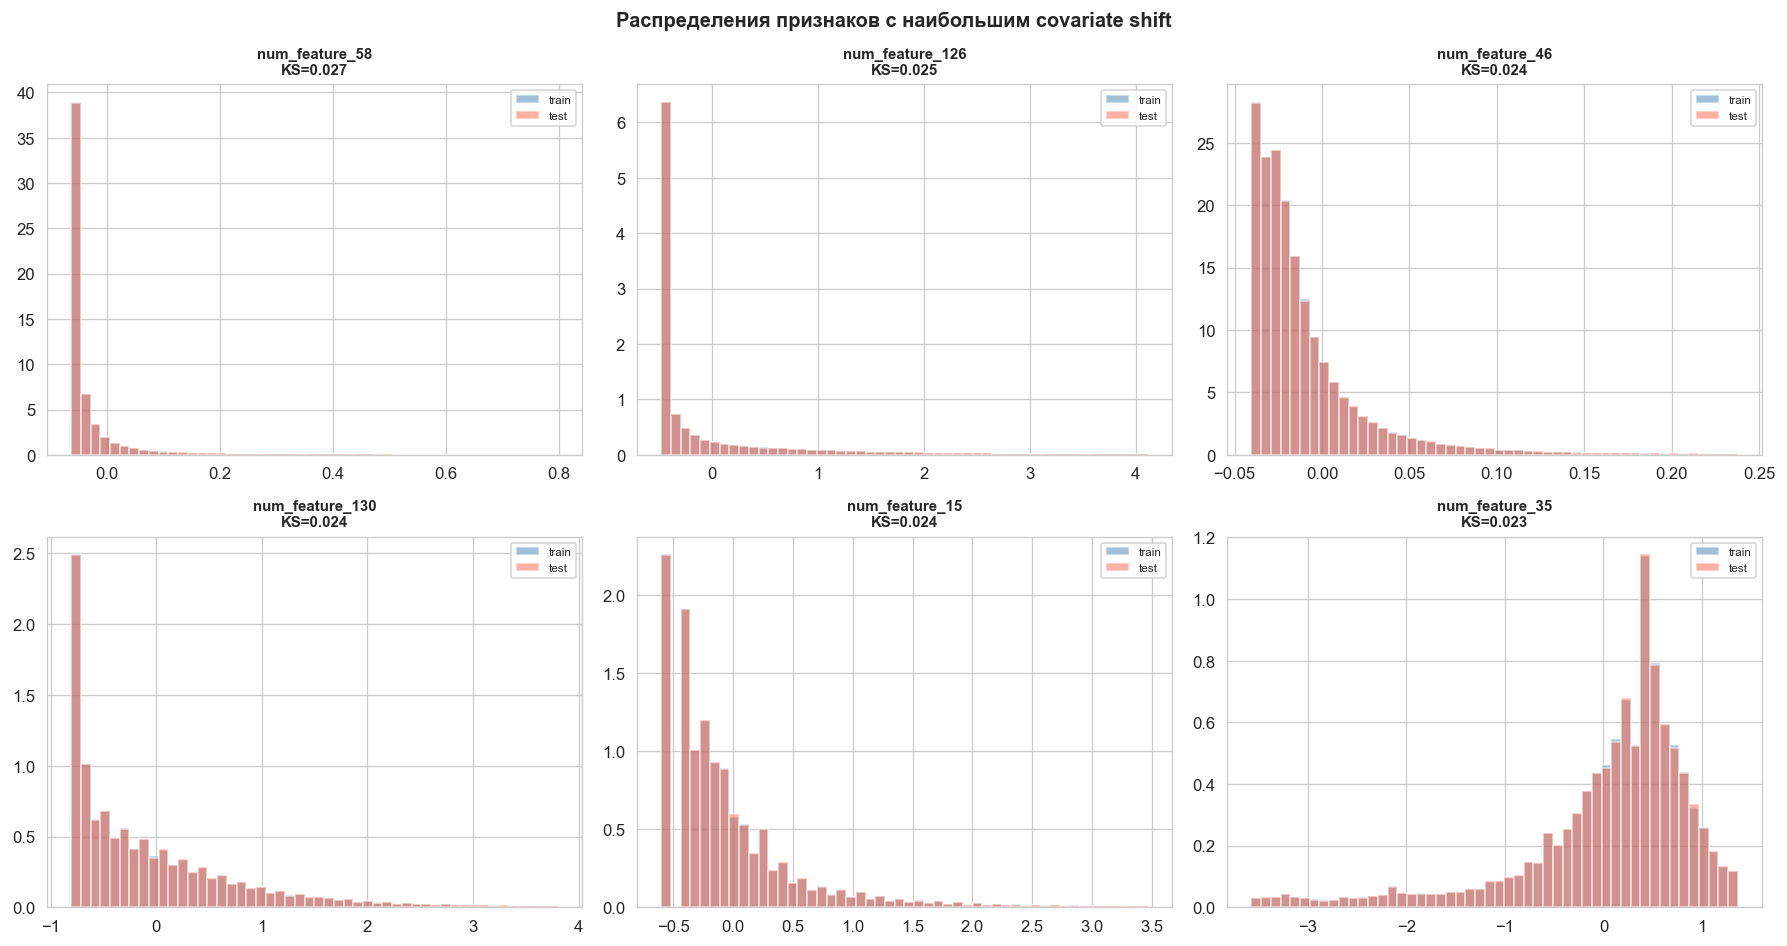

In [38]:
# Визуализация распределений для признаков с наибольшим KS
top_shifted = ks_df.head(6)['feature'].to_list()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_shifted):
    tr_vals = train[col].drop_nulls().to_numpy()
    te_vals = test[col].drop_nulls().to_numpy()
    p1 = np.percentile(np.concatenate([tr_vals, te_vals]), 1)
    p99 = np.percentile(np.concatenate([tr_vals, te_vals]), 99)
    axes[i].hist(tr_vals[(tr_vals >= p1) & (tr_vals <= p99)], bins=50,
                 alpha=0.5, density=True, label='train', color='steelblue')
    axes[i].hist(te_vals[(te_vals >= p1) & (te_vals <= p99)], bins=50,
                 alpha=0.5, density=True, label='test', color='tomato')
    ks_val = ks_df.filter(pl.col('feature') == col)['ks_stat'][0]
    axes[i].set_title(f'{col}\nKS={ks_val:.3f}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Распределения признаков с наибольшим covariate shift', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Adversarial Validation

Обучаем классификатор отличать train от test. Если ROC AUC >> 0.5 — есть значимый сдвиг.

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Берём числовые признаки с малым % пропусков
adv_cols = (
    missing
    .filter((pl.col('feat_type') == 'numerical') & (pl.col('pct_missing') < 20))
    ['col'].to_list()
)
print(f'Признаков для adversarial validation: {len(adv_cols)}')

N_ADV = 20000
tr_idx = np.random.choice(n, size=N_ADV, replace=False)
te_idx = np.random.choice(len(test), size=N_ADV, replace=False)

X_tr = train[tr_idx].select(adv_cols).to_numpy()
X_te = test[te_idx].select(adv_cols).to_numpy()

# Заполняем NaN медианой по train
col_medians = np.nanmedian(X_tr, axis=0)
for j in range(X_tr.shape[1]):
    X_tr[np.isnan(X_tr[:, j]), j] = col_medians[j]
    X_te[np.isnan(X_te[:, j]), j] = col_medians[j]

X_adv = np.vstack([X_tr, X_te])
y_adv = np.array([0] * N_ADV + [1] * N_ADV)

clf = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=SEED)
scores = cross_val_score(clf, X_adv, y_adv, cv=3, scoring='roc_auc')
print(f'\nAdversarial ROC AUC: {scores.mean():.4f} ± {scores.std():.4f}')
if scores.mean() > 0.55:
    print('⚠️  Значимый covariate shift! Стоит взвесить train или исключить нестабильные признаки.')
else:
    print('✓  Shift минимален, train и test распределены схоже.')

Признаков для adversarial validation: 14

Adversarial ROC AUC: 0.5048 ± 0.0051
✓  Shift минимален, train и test распределены схоже.


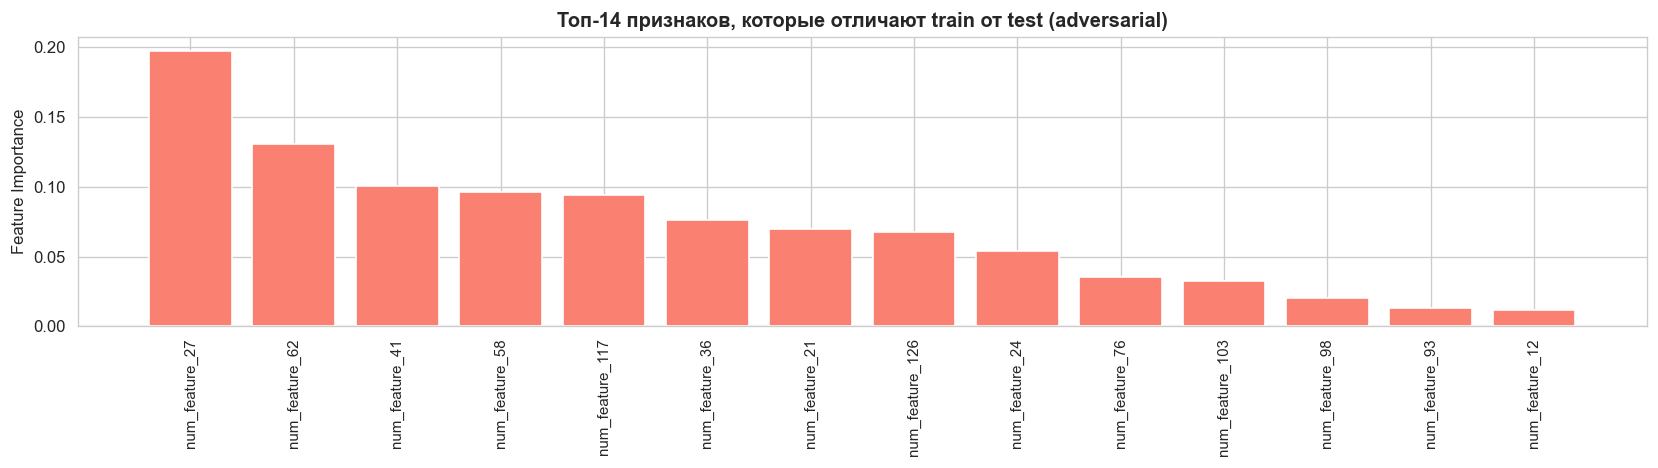

In [41]:
# Feature importances adversarial модели
clf.fit(X_adv, y_adv)
adv_importances = clf.feature_importances_
adv_imp_df = pl.DataFrame({'feature': adv_cols, 'importance': adv_importances.tolist()})
adv_imp_df = adv_imp_df.sort('importance', descending=True)

n_show = min(20, len(adv_imp_df))
top_adv = adv_imp_df.head(n_show)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(n_show), top_adv['importance'].to_numpy(), color='salmon')
ax.set_xticks(range(n_show))
ax.set_xticklabels(top_adv['feature'].to_list(), rotation=90, fontsize=9)
ax.set_title(f'Топ-{n_show} признаков, которые отличают train от test (adversarial)', fontweight='bold')
ax.set_ylabel('Feature Importance')
plt.tight_layout()
plt.show()

## 8. Финальные выводы

In [42]:
print('=' * 60)
print('ИТОГИ EDA: main_features')
print('=' * 60)

print(f"""
СТРУКТУРА ДАННЫХ
  Train: {train.shape[0]:,} строк, {train.shape[1]} признаков
  Test:  {test.shape[0]:,} строк
  Кат. признаков: {len(cat_cols)}, Числовых: {len(num_cols)}, Таргетов: {len(target_cols)}

ПРОПУСКИ
  Признаков с пропусками: {len(missing)}
  С >95% пропусков: {(missing['pct_missing'] > 95).sum()} (потенциально удалить)
  Рекомендация: создать индикаторы пропусков для признаков с 5-95% missing

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ  
  Медиана кардинальности: {int(np.median(cardinalities))}
  Признаков с >50 уникальными: {(cardinalities > 50).sum()} (аккуратно с OHE)
  Новых категорий в test: проверить unseen_df выше

ЧИСЛОВЫЕ ПРИЗНАКИ
  Признаков с высокой асимметрией |skew|>3: {len(high_skew)}
  Пар с высокой корреляцией |r|>0.9: {len(high_corr)} (кандидаты на удаление)

ТАРГЕТЫ
  Редких таргетов (<1%): {len(rare)} — нужны class weights / oversampling
  Средний prevalence: {prevalence.mean()*100:.1f}%

COVARIATE SHIFT
  Признаков с KS > 0.1: {len(shifted)} (осторожно использовать как признаки)

КЛЮЧЕВЫЕ РЕКОМЕНДАЦИИ
  1. Добавить индикаторы пропусков (MNAR-сигнал)
  2. Убрать/объединить высококоррелированные признаки
  3. Для редких таргетов: scale_pos_weight или отдельные модели
  4. Признаки с высоким adversarial importance — исключить или взвесить
  5. Подключить extra_features и повторить EDA
""")

ИТОГИ EDA: main_features

СТРУКТУРА ДАННЫХ
  Train: 750,000 строк, 200 признаков
  Test:  250,000 строк
  Кат. признаков: 67, Числовых: 132, Таргетов: 41

ПРОПУСКИ
  Признаков с пропусками: 132
  С >95% пропусков: 18 (потенциально удалить)
  Рекомендация: создать индикаторы пропусков для признаков с 5-95% missing

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ  
  Медиана кардинальности: 3
  Признаков с >50 уникальными: 3 (аккуратно с OHE)
  Новых категорий в test: проверить unseen_df выше

ЧИСЛОВЫЕ ПРИЗНАКИ
  Признаков с высокой асимметрией |skew|>3: 115
  Пар с высокой корреляцией |r|>0.9: 358 (кандидаты на удаление)

ТАРГЕТЫ
  Редких таргетов (<1%): 24 — нужны class weights / oversampling
  Средний prevalence: 3.2%

COVARIATE SHIFT
  Признаков с KS > 0.1: 0 (осторожно использовать как признаки)

КЛЮЧЕВЫЕ РЕКОМЕНДАЦИИ
  1. Добавить индикаторы пропусков (MNAR-сигнал)
  2. Убрать/объединить высококоррелированные признаки
  3. Для редких таргетов: scale_pos_weight или отдельные модели
  4. Признаки с высоким 